In [45]:
# [setup]
import pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [46]:
# [config]
PKL_DIR = Path("data-mozaic/comparisons/april/2026-02-27")


In [47]:
# [load-mozaics]
all_mozaics = {}
for pkl_path in sorted(PKL_DIR.glob("mozaic_objects.*.pkl")):
    with open(pkl_path, 'rb') as f:
        mozaics_dict = pickle.load(f)
    all_mozaics[pkl_path.stem] = mozaics_dict
    print(f"Loaded {pkl_path.name}: metrics = {list(mozaics_dict.keys())}")
print(f"\nTotal: {len(all_mozaics)} files, {sum(len(v) for v in all_mozaics.values())} mozaic objects")

Loaded mozaic_objects.glean_mobile.2026-02-27.pkl: metrics = ['DAU']
Loaded mozaic_objects.legacy_desktop.2026-02-27.pkl: metrics = ['DAU']

Total: 2 files, 2 mozaic objects


In [48]:
# [inspect-structure]
for file_stem, mozaics_dict in all_mozaics.items():
    print(f"\n=== {file_stem} ===")
    for metric, moz in mozaics_dict.items():
        model = moz._prophet_model
        hist = moz._prophet_model.history
        print(f"  Metric: {metric}")
        print(f"    Training period: {hist['ds'].min().date()} to {hist['ds'].max().date()} ({len(hist)} days)")
        print(f"    Forecast period: {moz.forecast_start_date} to {moz.forecast_end_date}")
        print(f"    Changepoints: {len(model.changepoints)}")
        deltas = model.params['delta'][0]
        changepoints = model.changepoints.values  # convert to numpy array for positional indexing
        top_idx = np.argsort(np.abs(deltas))[-3:][::-1]
        print(f"    Largest |delta|: " + ", ".join(
            f"{pd.Timestamp(changepoints[i]).date()} (delta={deltas[i]:.3f})" for i in top_idx
        ))



=== mozaic_objects.glean_mobile.2026-02-27 ===
  Metric: DAU
    Training period: 2020-12-31 to 2026-02-26 (1884 days)
    Forecast period: 2026-02-27 to 2027-12-31
    Changepoints: 25
    Largest |delta|: 2021-03-03 (delta=-3.383), 2022-01-05 (delta=-1.000), 2021-09-04 (delta=0.805)

=== mozaic_objects.legacy_desktop.2026-02-27 ===
  Metric: DAU
    Training period: 2020-01-01 to 2026-02-26 (2249 days)
    Forecast period: 2026-02-27 to 2027-12-31
    Changepoints: 25
    Largest |delta|: 2021-01-13 (delta=-2.016), 2020-11-11 (delta=-1.591), 2021-03-16 (delta=-1.400)


In [49]:
# [define-helpers]

def get_historical_predictions(moz):
    """Run Prophet predict() over the training period to get in-sample decomposition."""
    model = moz._prophet_model
    hist_df = model.history[['ds', 'cap', 'floor']].copy()
    return model.predict(hist_df)


def get_yearly_seasonality_pattern(moz):
    """Generate one full year of predictions to isolate the yearly seasonal component.

    Returns a DataFrame with day-of-year (1-365) as index and the 'yearly' column.
    We use a non-leap year in the middle of the training range to get a representative pattern.
    """
    model = moz._prophet_model
    hist = model.history
    cap_val = hist['cap'].median()
    floor_val = hist['floor'].median()

    year_dates = pd.date_range('2022-01-01', '2022-12-31', freq='D')
    year_df = pd.DataFrame({
        'ds': year_dates,
        'cap': cap_val,
        'floor': floor_val,
    })
    pred = model.predict(year_df)
    pred['day_of_year'] = pred['ds'].dt.dayofyear
    return pred[['ds', 'day_of_year', 'yearly', 'yearly_lower', 'yearly_upper']]


def get_weekly_seasonality_pattern(moz):
    """Generate one full week of predictions to isolate the weekly seasonal component.

    Returns a DataFrame with weekday names as labels.
    """
    model = moz._prophet_model
    hist = model.history
    cap_val = hist['cap'].median()
    floor_val = hist['floor'].median()

    # Use a Monday-starting week
    week_dates = pd.date_range('2022-01-03', '2022-01-09', freq='D')  # Mon-Sun
    week_df = pd.DataFrame({
        'ds': week_dates,
        'cap': cap_val,
        'floor': floor_val,
    })
    pred = model.predict(week_df)
    pred['day_name'] = pred['ds'].dt.day_name()
    return pred[['ds', 'day_name', 'weekly', 'weekly_lower', 'weekly_upper']]


def build_changepoint_info(moz):
    """Extract changepoints with delta magnitudes for plotting.

    Returns a DataFrame with columns: date, delta, abs_delta, direction.
    The 'alpha' column is kept for the trend subplot (unused on main plot).
    """
    model = moz._prophet_model
    deltas = model.params['delta'][0]  # shape (n_changepoints,)
    df = pd.DataFrame({
        'date': model.changepoints,
        'delta': deltas,
        'abs_delta': np.abs(deltas),
    })
    df['direction'] = np.where(df['delta'] > 0, 'up', 'down')
    df = df.reset_index(drop=True)
    return df


def filter_significant_changepoints(cp_df, threshold_fraction=0.1):
    """Return only changepoints whose |delta| exceeds a fraction of the median |delta|.

    Changepoints with near-zero delta are Prophet artefacts from uniform prior placement
    and add visual noise without conveying real trend shifts.

    Args:
        cp_df: DataFrame from build_changepoint_info()
        threshold_fraction: minimum |delta| as a fraction of the median |delta| (default 0.1)

    Returns:
        Filtered DataFrame containing only significant changepoints.
    """
    threshold = threshold_fraction * cp_df['abs_delta'].median()
    return cp_df[cp_df['abs_delta'] >= threshold].copy()


In [50]:
# [plot-functions]

COLOR_ACTUAL = '#4a90d9'
COLOR_MA = '#1a5fa8'
COLOR_FORECAST = '#e07b39'
COLOR_FORECAST_BAND = '#f5c99a'
COLOR_TREND = '#555555'
COLOR_CP_MAIN = '#9467bd'   # single color for all significant changepoints on main plot
COLOR_CP_UP = '#2ca02c'
COLOR_CP_DOWN = '#d62728'
MA_WINDOW = 28  # days
CP_THRESHOLD_FRACTION = 0.1  # |delta| must be >= this fraction of median |delta| to show on main plot


def plot_mozaic_changepoints(moz, title, fig_width=22):
    """Plot a Mozaic object's changepoints, forecast, and seasonal decomposition.

    Layout:
      - Top panel (large): historical actuals + 28-day MA, forecast with CI band,
        trend overlay, significant changepoint verticals (all annotated)
      - Bottom row (4 panels): trend, yearly seasonality, weekly seasonality,
        changepoint delta magnitudes (bar chart)
    """
    import time
    t0 = time.time()
    print(f"Computing predictions for: {title}")

    model = moz._prophet_model
    hist_df = model.history
    forecast_df = moz._prophet_forecast
    forecast_dates = moz.forecast_dates
    forecast_start = pd.Timestamp(moz.forecast_start_date)

    # --- Historical actuals (from raw history, in original scale) ---
    hist_dates = pd.to_datetime(hist_df['ds'])
    hist_vals = hist_df['y']  # use original unscaled y; y_scaled omits the floor term
    hist_ma = pd.Series(hist_vals.values, index=hist_dates).rolling(MA_WINDOW, center=True).mean()

    # --- In-sample predictions for trend ---
    print(f"  Running in-sample predict()...")
    hist_pred = get_historical_predictions(moz)
    print(f"  Done ({time.time()-t0:.1f}s)")

    # Full trend: historical + forecast
    full_trend_dates = pd.concat([
        hist_pred['ds'],
        forecast_df['ds']
    ]).reset_index(drop=True)
    full_trend_vals = pd.concat([
        hist_pred['trend'],
        forecast_df['trend']
    ]).reset_index(drop=True)

    # --- Forecast samples: median + 10th/90th percentile ---
    forecast_samples = moz.forecast  # (n_forecast_dates, n_samples)
    forecast_median = forecast_samples.median(axis=1).values
    forecast_lo = forecast_samples.quantile(0.1, axis=1).values
    forecast_hi = forecast_samples.quantile(0.9, axis=1).values

    # --- Changepoints: all (for bar chart + trend panel) and significant (for main plot) ---
    cp_df = build_changepoint_info(moz)
    cp_significant = filter_significant_changepoints(cp_df, threshold_fraction=CP_THRESHOLD_FRACTION)
    threshold_value = CP_THRESHOLD_FRACTION * cp_df['abs_delta'].median()
    print(f"  Changepoints: {len(cp_df)} total, {len(cp_significant)} significant (|delta| >= {threshold_value:.3f})")

    # --- Seasonality patterns ---
    yearly_pat = get_yearly_seasonality_pattern(moz)
    weekly_pat = get_weekly_seasonality_pattern(moz)

    # ---- Build figure ----
    fig = plt.figure(figsize=(fig_width, 14))
    gs = gridspec.GridSpec(
        2, 4,
        height_ratios=[2.2, 1],
        hspace=0.42,
        wspace=0.35,
        left=0.06, right=0.97, top=0.93, bottom=0.07,
    )
    ax_main = fig.add_subplot(gs[0, :])   # spans all 4 columns
    ax_trend = fig.add_subplot(gs[1, 0])
    ax_yearly = fig.add_subplot(gs[1, 1])
    ax_weekly = fig.add_subplot(gs[1, 2])
    ax_cp_mag = fig.add_subplot(gs[1, 3])

    # ---- Main panel ----
    # Raw historical (faint)
    ax_main.plot(hist_dates, hist_vals / 1e6, color=COLOR_ACTUAL, alpha=0.25, linewidth=0.6, label='Actual (daily)')
    # 28-day MA
    ax_main.plot(hist_ma.index, hist_ma.values / 1e6, color=COLOR_MA, linewidth=1.5, label=f'{MA_WINDOW}-day MA')

    # Forecast CI band
    ax_main.fill_between(
        forecast_dates, forecast_lo / 1e6, forecast_hi / 1e6,
        color=COLOR_FORECAST_BAND, alpha=0.6, label='Forecast 10-90% CI'
    )
    # Forecast median
    ax_main.plot(forecast_dates, forecast_median / 1e6, color=COLOR_FORECAST, linewidth=2.0, label='Forecast (median)')

    # Trend overlay (thin dashed)
    ax_main.plot(full_trend_dates, full_trend_vals / 1e6, color=COLOR_TREND, linewidth=1.0,
                 linestyle='--', alpha=0.7, label='Trend')

    # Significant changepoint verticals — single solid color/alpha
    for _, cp in cp_significant.iterrows():
        ax_main.axvline(cp['date'], color=COLOR_CP_MAIN, alpha=0.6, linewidth=1.2, zorder=2)

    # Forecast start boundary
    ax_main.axvline(forecast_start, color='black', linewidth=1.5, linestyle=':', alpha=0.6)

    # Formatting
    ax_main.xaxis.set_major_locator(mdates.YearLocator())
    ax_main.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
    ax_main.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax_main.set_ylabel('DAU (millions)')
    ax_main.set_title(title, fontsize=13, fontweight='bold')
    ax_main.grid(True, which='major', alpha=0.3)
    ax_main.grid(True, which='minor', alpha=0.1)

    # Custom legend
    handles, labels = ax_main.get_legend_handles_labels()
    handles += [
        Line2D([0], [0], color=COLOR_CP_MAIN, linewidth=1.5, label='Changepoint (significant)'),
        Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label='Forecast start'),
    ]
    ax_main.legend(handles=handles, loc='upper right', fontsize=8, ncol=2)

    # Annotate all significant changepoints — stagger vertically to reduce label collisions
    ax_ylim = ax_main.get_ylim()
    span = ax_ylim[1] - ax_ylim[0]
    annotation_levels = [
        ax_ylim[0] + 0.97 * span,
        ax_ylim[0] + 0.88 * span,
    ]
    for row_idx, (_, cp) in enumerate(cp_significant.iterrows()):
        sign = '+' if cp['delta'] > 0 else ''
        annotation_y = annotation_levels[row_idx % 2]
        ax_main.annotate(
            f"{cp['date'].strftime('%y-%m')}\n{sign}{cp['delta']:.2f}",
            xy=(cp['date'], annotation_y),
            fontsize=5.5, ha='center', va='top', color='#333333',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.75),
        )

    # ---- Trend panel ----
    ax_trend.plot(full_trend_dates, full_trend_vals / 1e6, color=COLOR_TREND, linewidth=1.4)
    ax_trend.axvline(forecast_start, color='black', linewidth=1.2, linestyle=':', alpha=0.6)
    for _, cp in cp_df.iterrows():
        color = COLOR_CP_UP if cp['direction'] == 'up' else COLOR_CP_DOWN
        ax_trend.axvline(cp['date'], color=color, alpha=0.5, linewidth=0.9)
    ax_trend.xaxis.set_major_locator(mdates.YearLocator())
    ax_trend.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
    ax_trend.set_ylabel('Millions')
    ax_trend.set_title('Trend', fontweight='bold')
    ax_trend.grid(True, alpha=0.3)

    # ---- Yearly seasonality panel ----
    ax_yearly.fill_between(
        yearly_pat['day_of_year'],
        yearly_pat['yearly_lower'],
        yearly_pat['yearly_upper'],
        alpha=0.3, color='steelblue'
    )
    ax_yearly.plot(yearly_pat['day_of_year'], yearly_pat['yearly'], color='steelblue', linewidth=1.4)
    ax_yearly.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
    month_starts = yearly_pat.groupby(yearly_pat['ds'].dt.month)['day_of_year'].min()
    month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    ax_yearly.set_xticks(month_starts.values)
    ax_yearly.set_xticklabels(month_labels, fontsize=8)
    ax_yearly.set_xlabel('Month')
    ax_yearly.set_title('Yearly Seasonality', fontweight='bold')
    ax_yearly.grid(True, alpha=0.3)

    # ---- Weekly seasonality panel ----
    ax_weekly.fill_between(
        range(7),
        weekly_pat['weekly_lower'],
        weekly_pat['weekly_upper'],
        alpha=0.3, color='mediumpurple'
    )
    ax_weekly.plot(range(7), weekly_pat['weekly'], color='mediumpurple', linewidth=1.4, marker='o', markersize=5)
    ax_weekly.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
    ax_weekly.set_xticks(range(7))
    ax_weekly.set_xticklabels(
        [d[:3] for d in weekly_pat['day_name']],
        fontsize=8
    )
    ax_weekly.set_xlabel('Day of week')
    ax_weekly.set_title('Weekly Seasonality', fontweight='bold')
    ax_weekly.grid(True, alpha=0.3)

    # ---- Changepoint magnitude bar chart ----
    bar_colors = [COLOR_CP_UP if d == 'up' else COLOR_CP_DOWN for d in cp_df['direction']]
    # Highlight significant bars; dim near-zero ones
    bar_alphas = [0.85 if abs_d >= threshold_value else 0.25 for abs_d in cp_df['abs_delta']]
    x_positions = range(len(cp_df))
    bars = ax_cp_mag.bar(x_positions, cp_df['delta'], color=bar_colors, width=0.7)
    for bar, alpha in zip(bars, bar_alphas):
        bar.set_alpha(alpha)
    ax_cp_mag.axhline(0, color='black', linewidth=0.7, linestyle='-', alpha=0.4)
    # Threshold lines
    ax_cp_mag.axhline(threshold_value, color=COLOR_CP_MAIN, linewidth=0.8, linestyle='--', alpha=0.6)
    ax_cp_mag.axhline(-threshold_value, color=COLOR_CP_MAIN, linewidth=0.8, linestyle='--', alpha=0.6)
    # x-axis: year labels at the first changepoint of each year
    cp_years = pd.to_datetime(cp_df['date']).dt.year
    year_first_idx = {yr: idx for idx, yr in enumerate(cp_years)}  # last occurrence wins; reverse to get first
    year_first_idx = {}
    for idx, yr in enumerate(cp_years):
        if yr not in year_first_idx:
            year_first_idx[yr] = idx
    ax_cp_mag.set_xticks(list(year_first_idx.values()))
    ax_cp_mag.set_xticklabels([str(yr) for yr in year_first_idx.keys()], fontsize=8)
    ax_cp_mag.set_xlim(-0.5, len(cp_df) - 0.5)
    ax_cp_mag.set_xlabel('Changepoint')
    ax_cp_mag.set_title('Changepoint Magnitudes (δ)', fontweight='bold')
    ax_cp_mag.grid(True, axis='y', alpha=0.3)

    print(f"  Plot complete ({time.time()-t0:.1f}s)")
    plt.show()



Computing predictions for: Glean Mobile — DAU  (forecast from 2026-02-27)
  Running in-sample predict()...
  Done (0.1s)
  Changepoints: 25 total, 17 significant (|delta| >= 0.007)
  Plot complete (0.2s)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

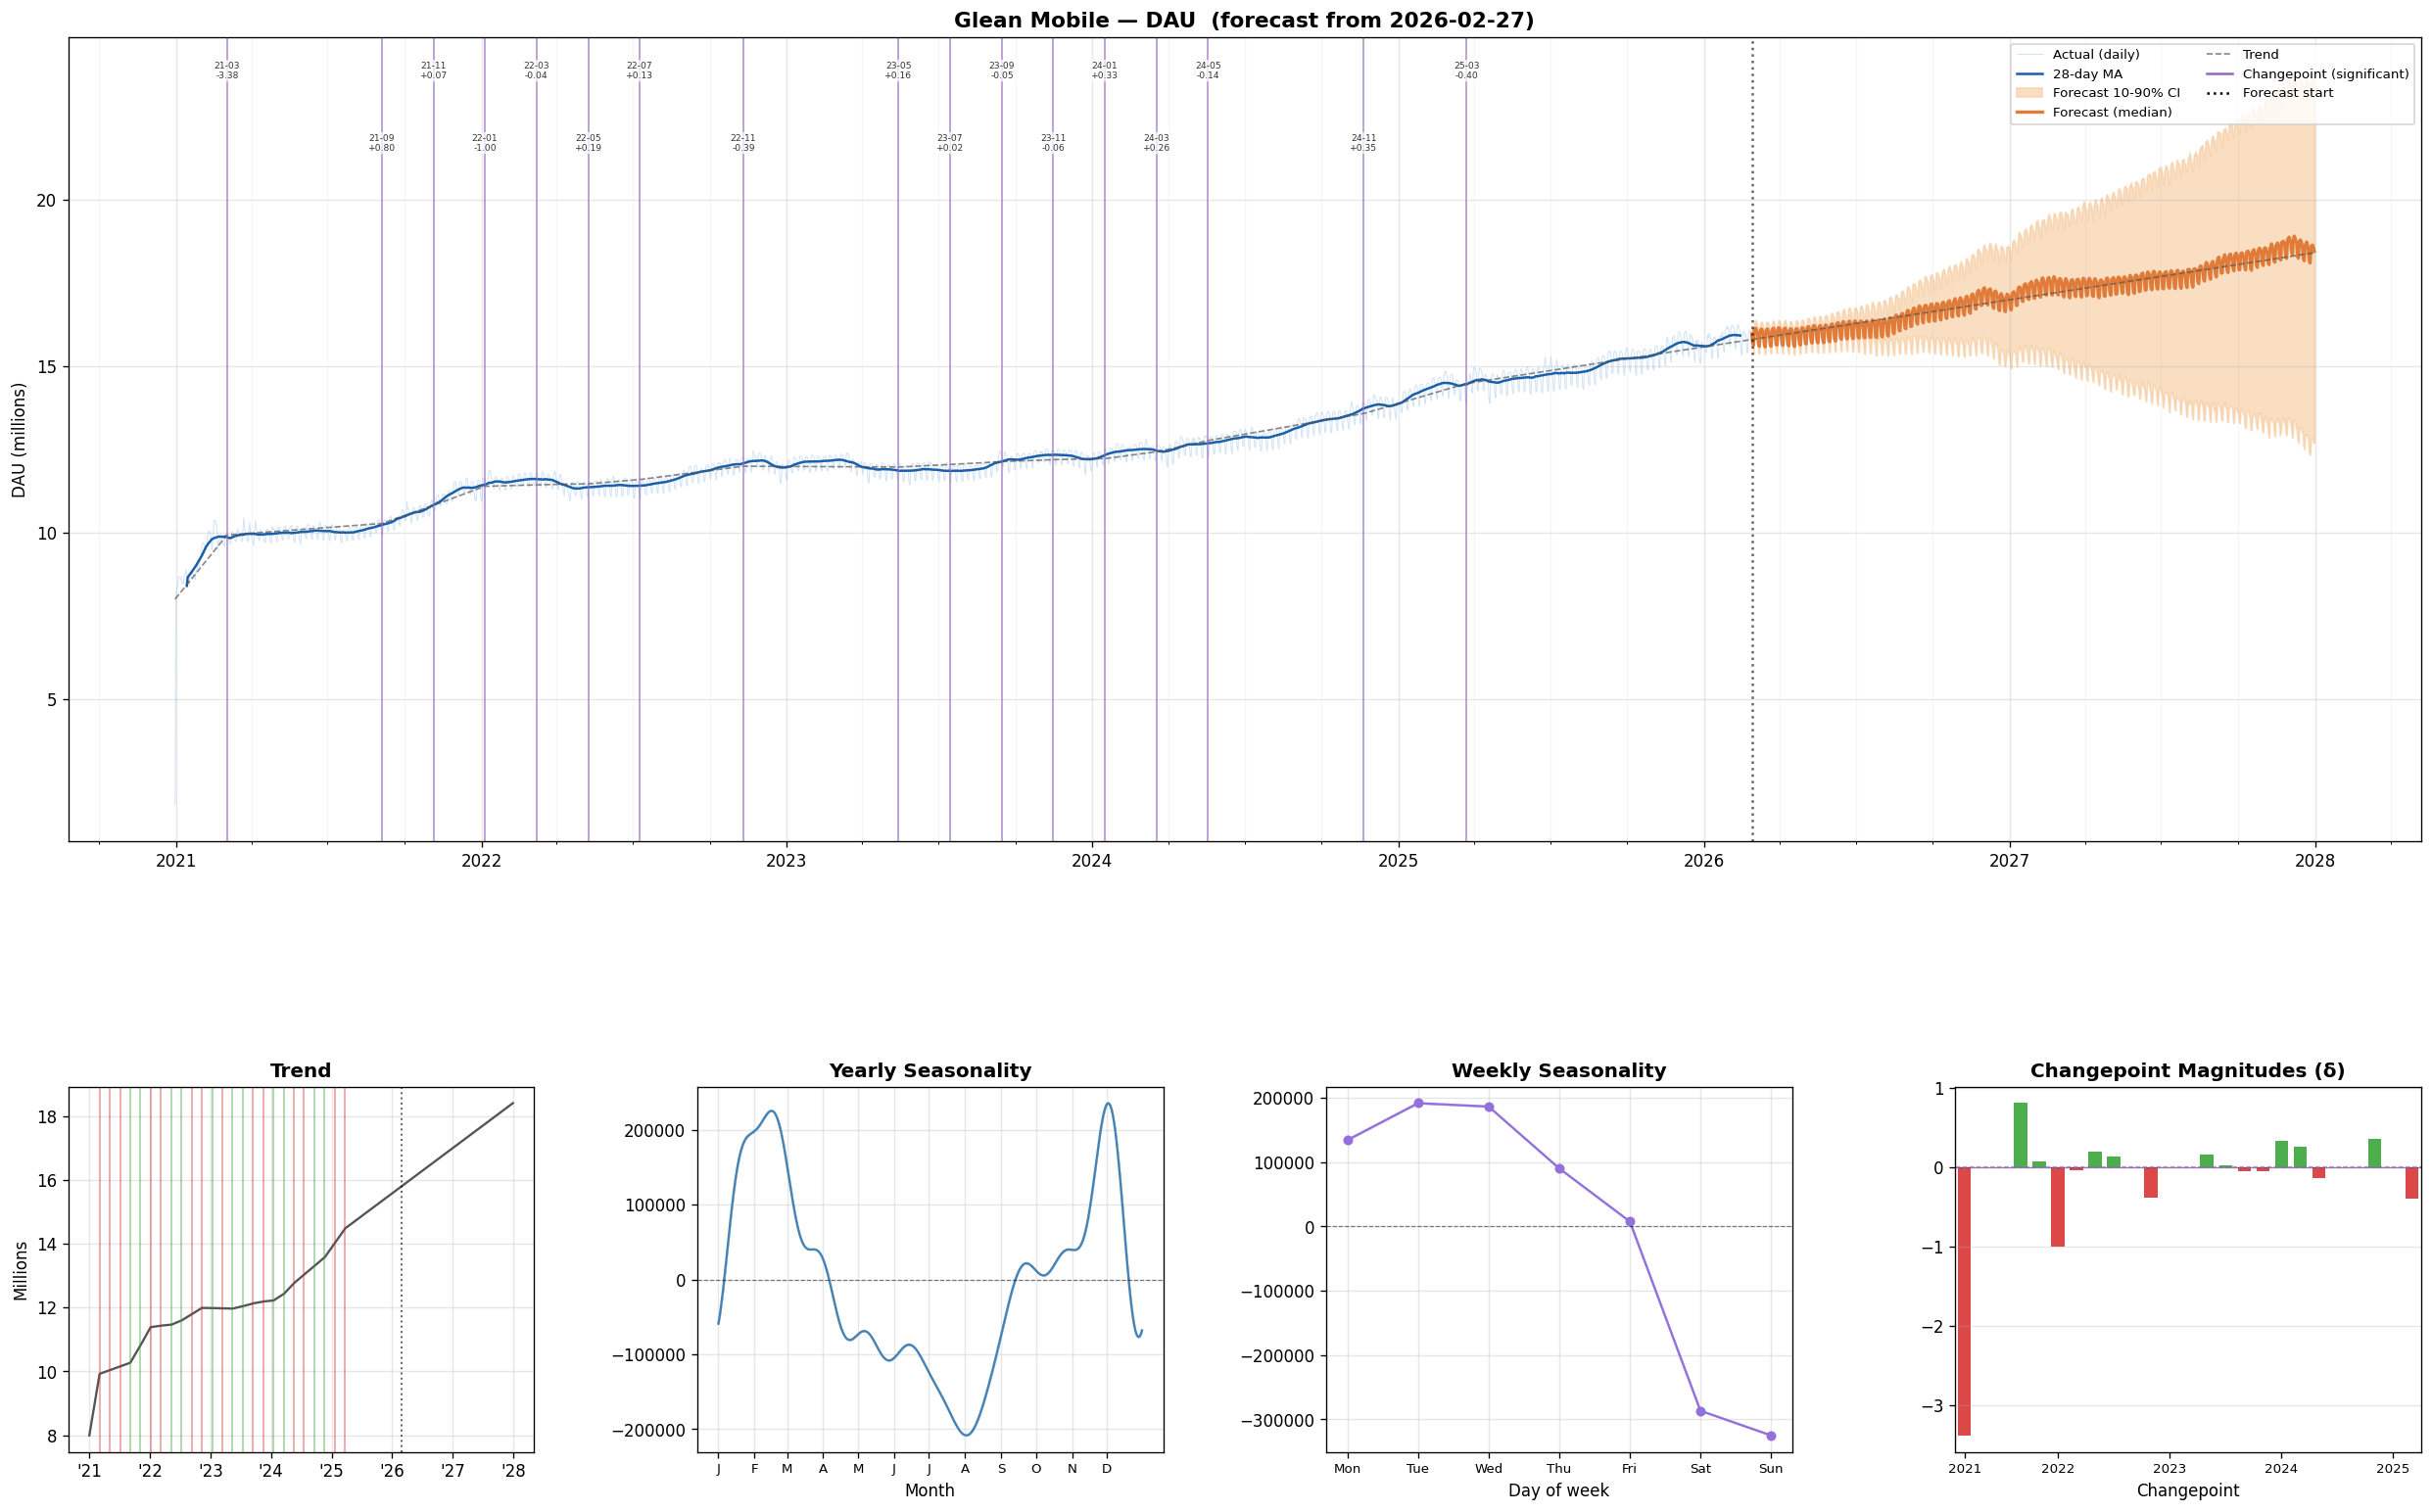

Computing predictions for: Legacy Desktop — DAU  (forecast from 2026-02-27)
  Running in-sample predict()...
  Done (0.1s)
  Changepoints: 25 total, 13 significant (|delta| >= 0.001)
  Plot complete (0.2s)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

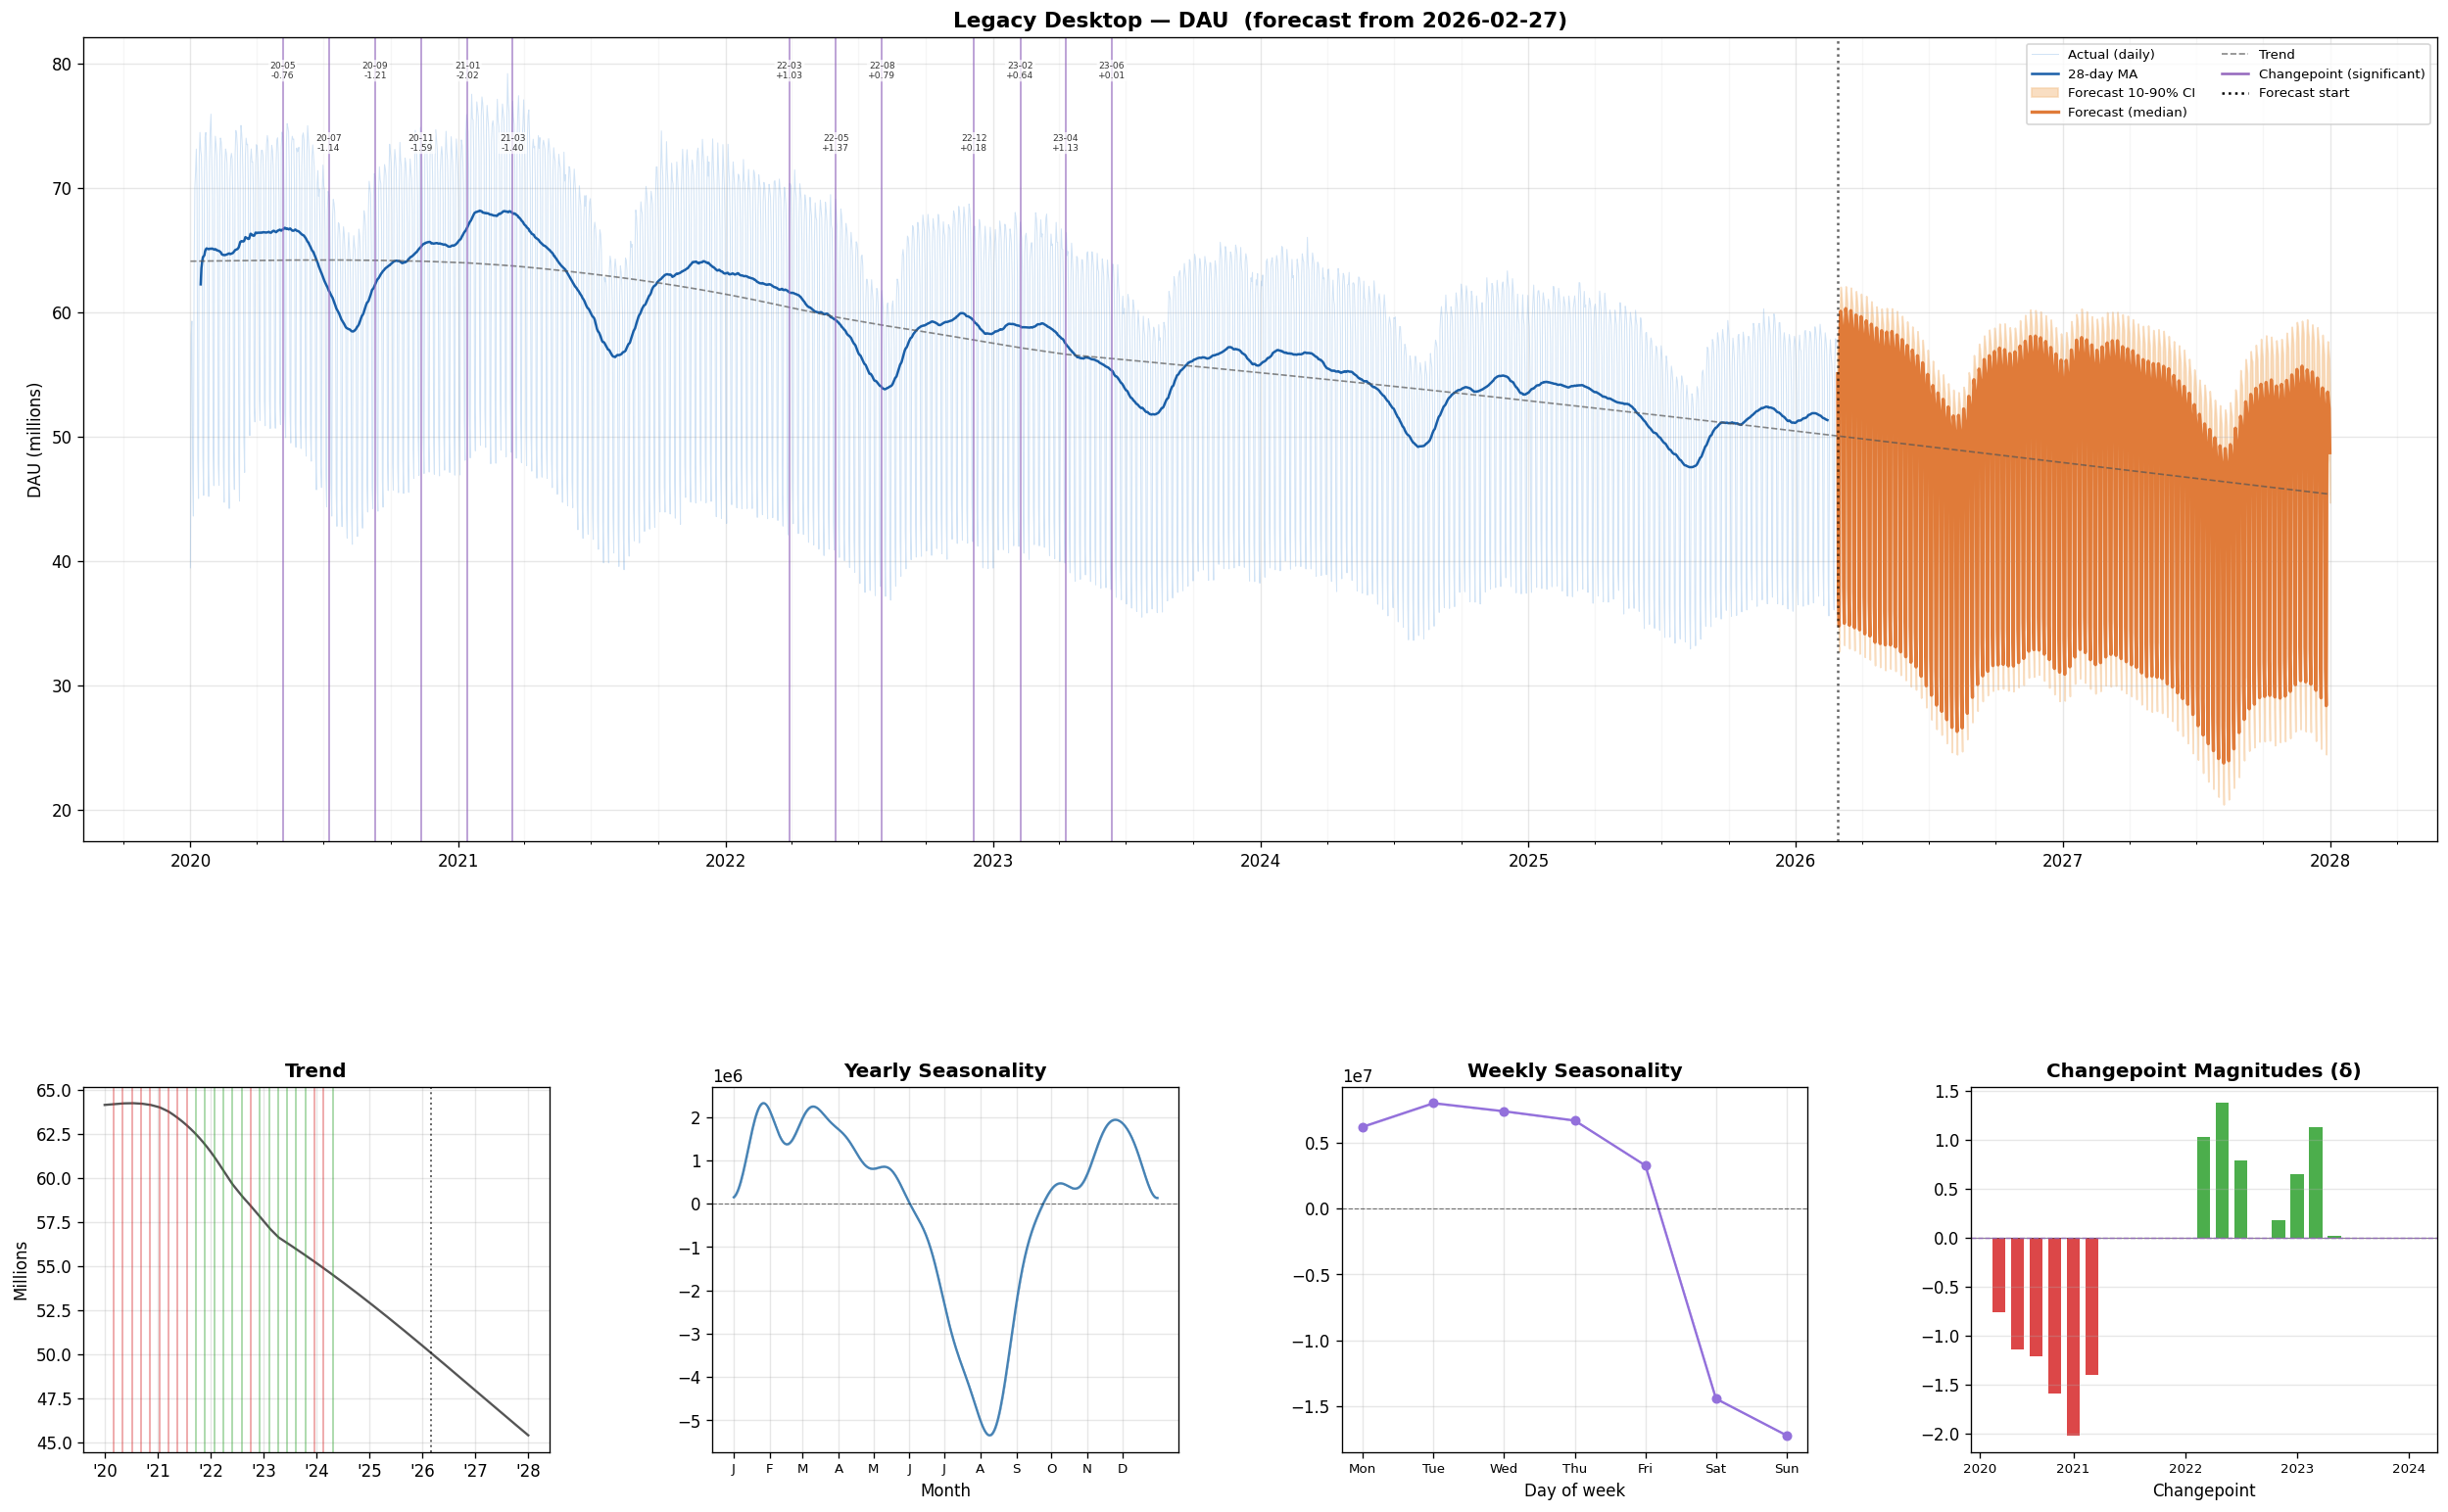

In [51]:
# [generate-plots]
for file_stem, mozaics_dict in all_mozaics.items():
    # Extract a readable source name from the file stem
    # e.g. mozaic_objects.legacy_desktop.2026-02-07 -> Legacy Desktop
    parts = file_stem.split('.')
    source_name = parts[1].replace('_', ' ').title() if len(parts) > 1 else file_stem
    forecast_date = parts[2] if len(parts) > 2 else ''

    for metric, moz in mozaics_dict.items():
        title = f"{source_name} — {metric}  (forecast from {forecast_date})"
        plot_mozaic_changepoints(moz, title=title)

---
## Comparison: `changepoint_range=0.90`

Data generated with `changepoint_range=0.90` (between the default 0.80 and the 0.96 variant).

In [52]:
# [load-mozaics-0.90]
PKL_DIR_090 = Path("data-mozaic/comparisons-0.90/april/2026-02-27")

all_mozaics_090 = {}
for pkl_path in sorted(PKL_DIR_090.glob("mozaic_objects.*.pkl")):
    with open(pkl_path, 'rb') as f:
        mozaics_dict = pickle.load(f)
    all_mozaics_090[pkl_path.stem] = mozaics_dict
    print(f"Loaded {pkl_path.name}: metrics = {list(mozaics_dict.keys())}")
print(f"\nTotal: {len(all_mozaics_090)} files, {sum(len(v) for v in all_mozaics_090.values())} mozaic objects")

Loaded mozaic_objects.glean_mobile.2026-02-27.pkl: metrics = ['DAU']
Loaded mozaic_objects.legacy_desktop.2026-02-27.pkl: metrics = ['DAU']

Total: 2 files, 2 mozaic objects


Computing predictions for: Glean Mobile — DAU  (forecast from 2026-02-27, changepoint_range=0.90)
  Running in-sample predict()...
  Done (0.1s)
  Changepoints: 25 total, 19 significant (|delta| >= 0.019)
  Plot complete (0.2s)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

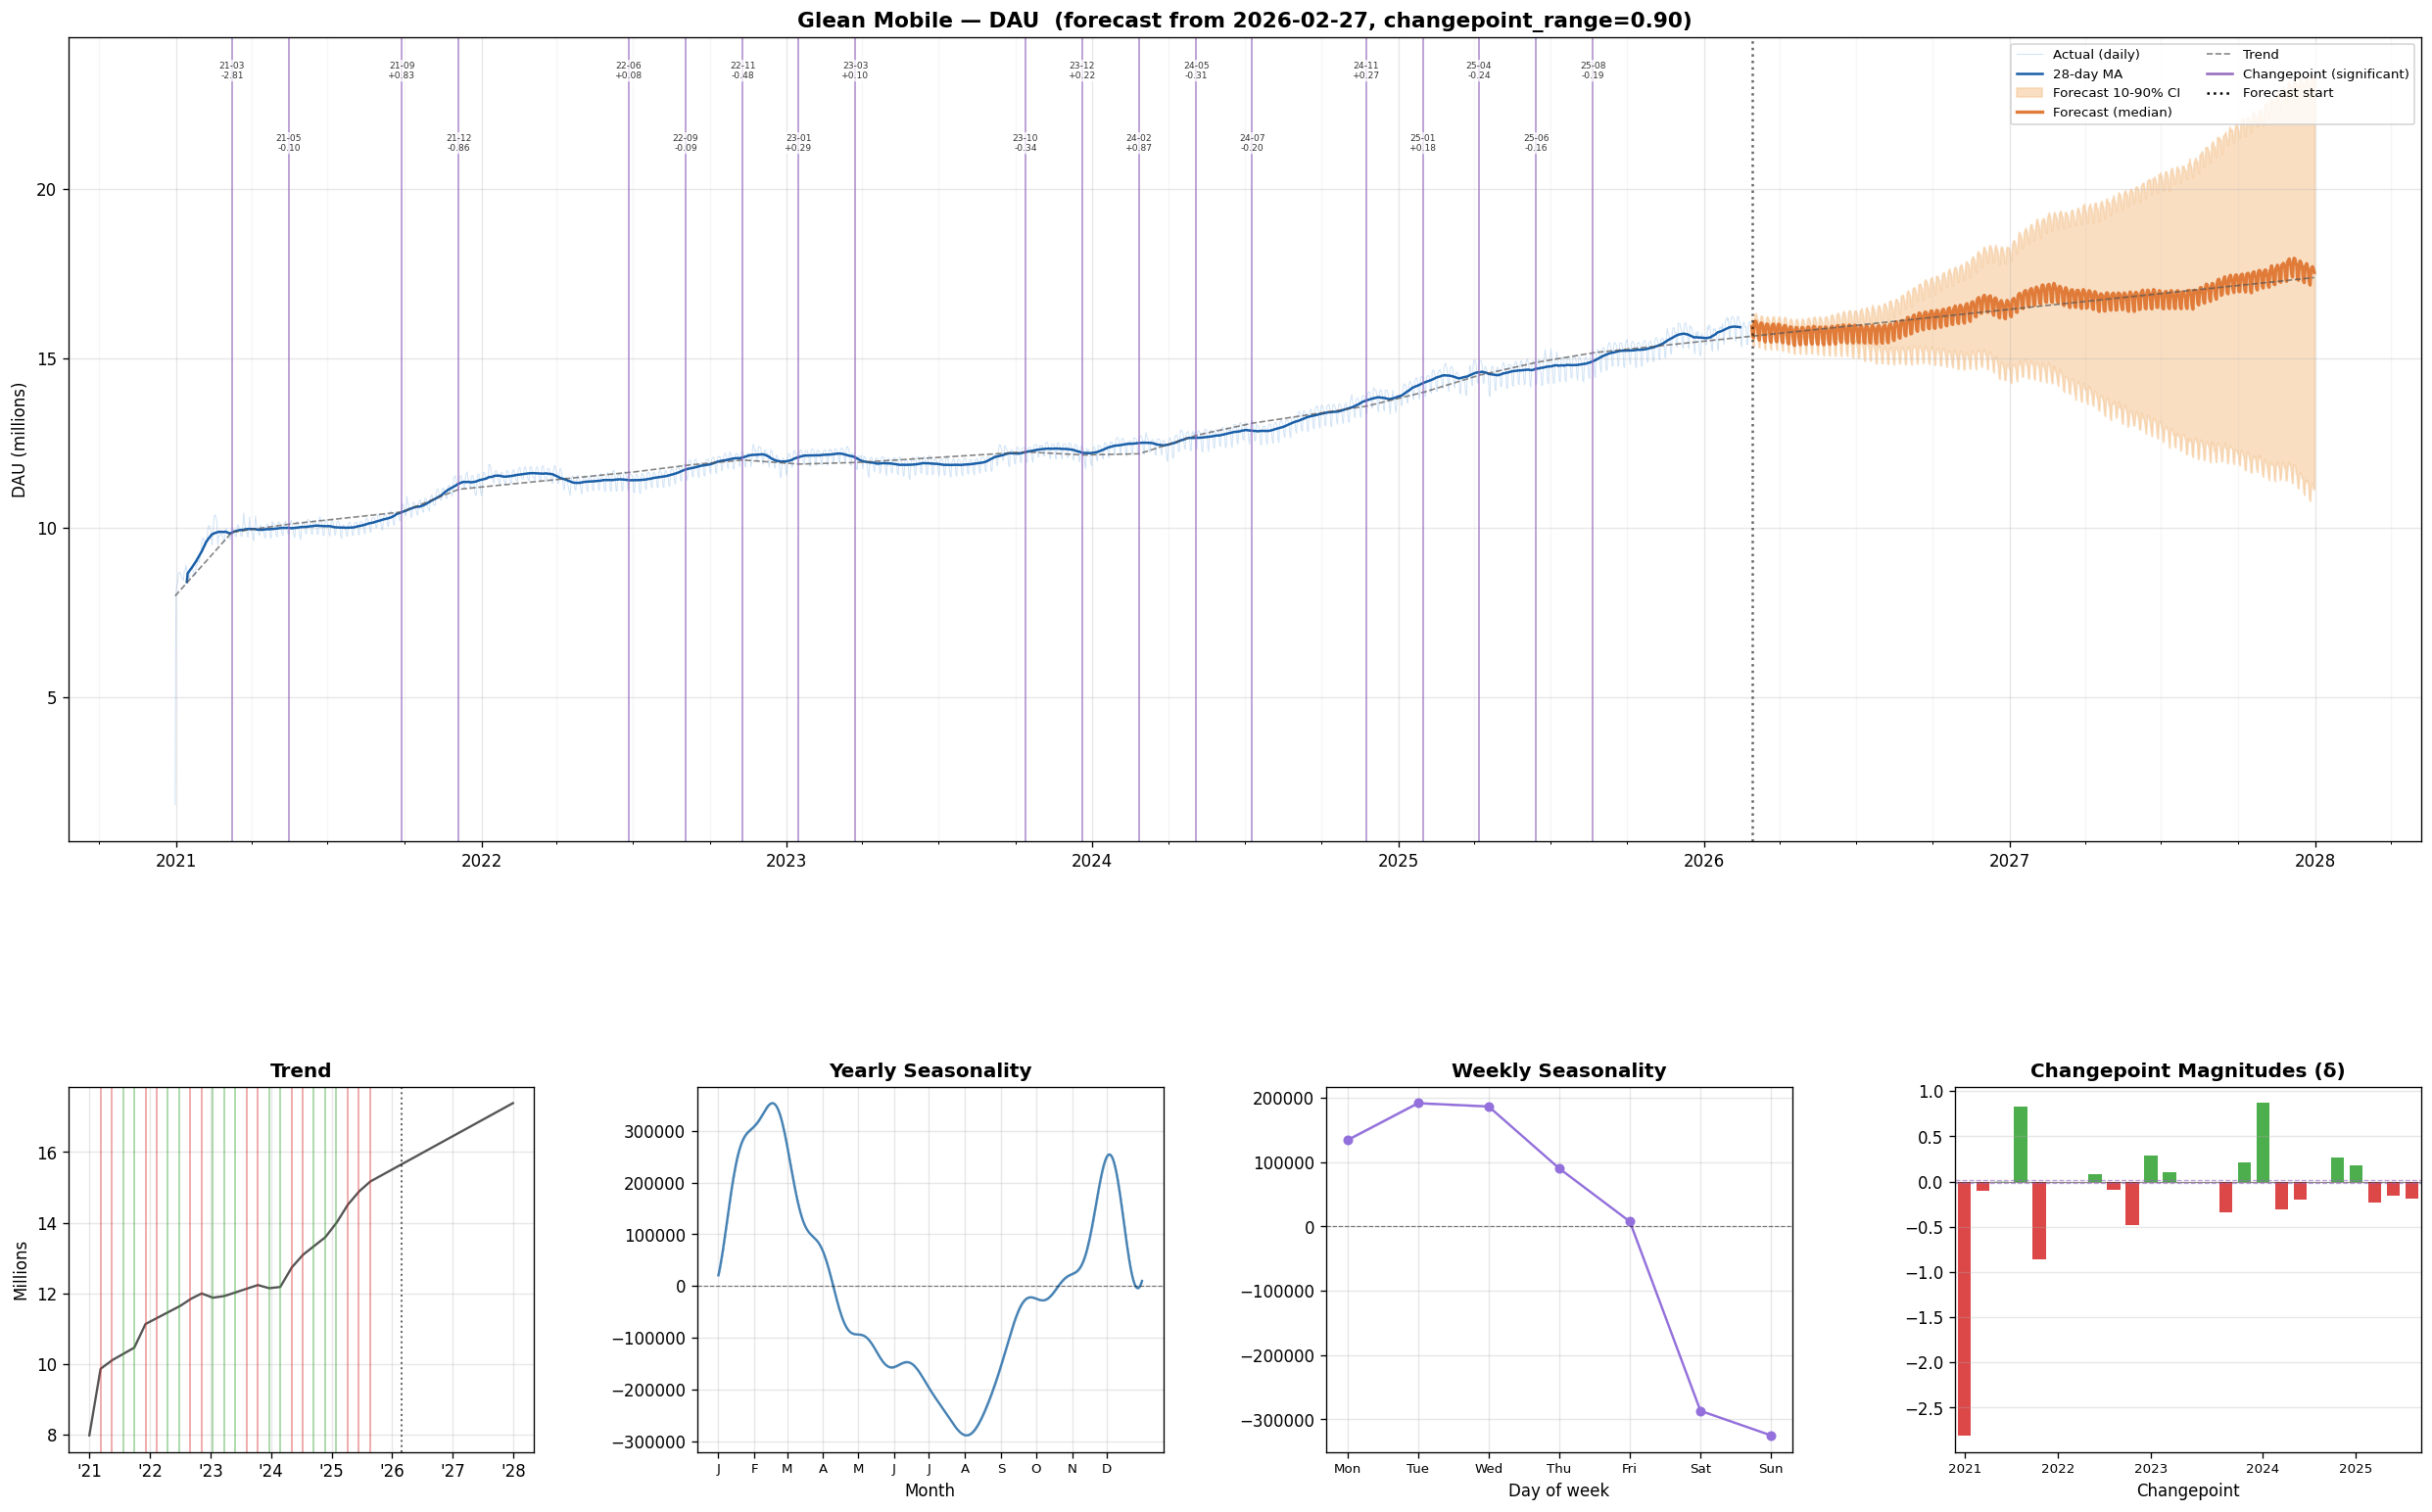

Computing predictions for: Legacy Desktop — DAU  (forecast from 2026-02-27, changepoint_range=0.90)
  Running in-sample predict()...
  Done (0.1s)
  Changepoints: 25 total, 13 significant (|delta| >= 0.000)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

  Plot complete (0.3s)


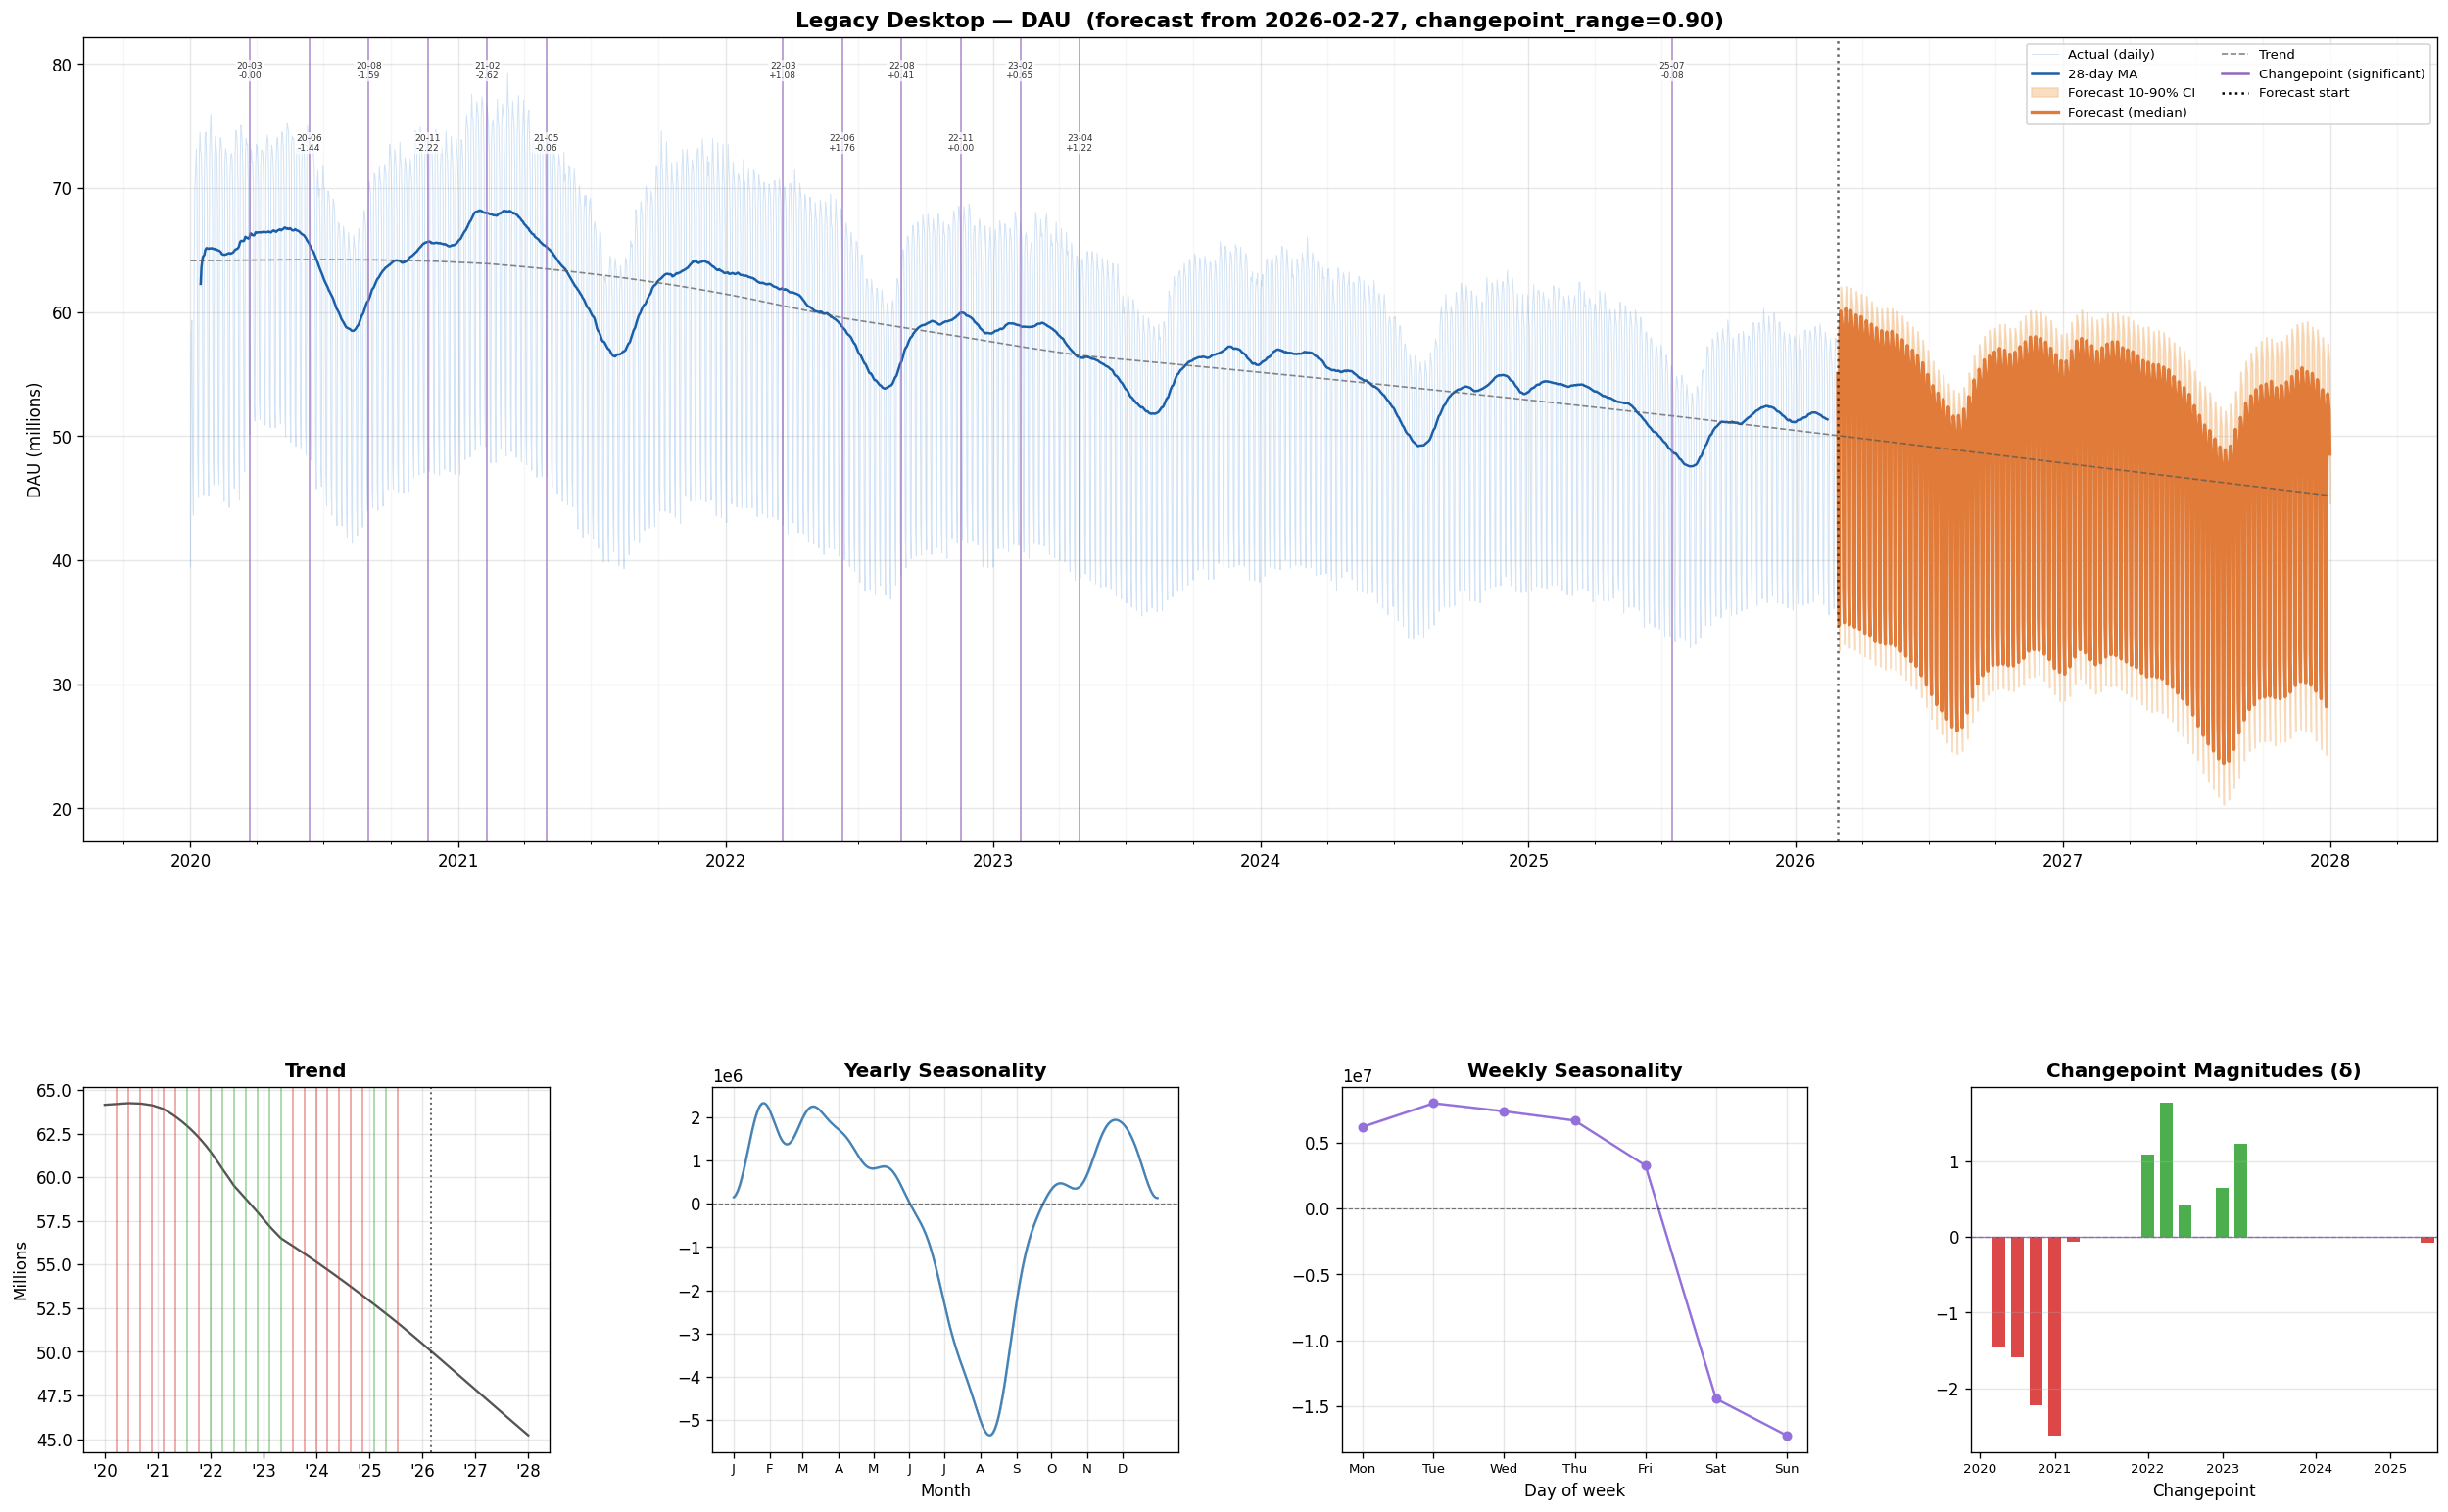

In [53]:
# [generate-plots-0.90]
for file_stem, mozaics_dict in all_mozaics_090.items():
    parts = file_stem.split('.')
    source_name = parts[1].replace('_', ' ').title() if len(parts) > 1 else file_stem
    forecast_date = parts[2] if len(parts) > 2 else ''

    for metric, moz in mozaics_dict.items():
        title = f"{source_name} — {metric}  (forecast from {forecast_date}, changepoint_range=0.90)"
        plot_mozaic_changepoints(moz, title=title)

---
## Comparison: `changepoint_range=0.96`

The cells below load data generated with a higher `changepoint_range` (0.96 vs the default 0.80) and produce the same plots for side-by-side comparison. A higher changepoint_range allows Prophet to place changepoints further into the training window, which can capture more recent trend shifts.

In [54]:
# [load-mozaics-0.96]
PKL_DIR_096 = Path("data-mozaic/comparisons-0.96/april/2026-02-27")

all_mozaics_096 = {}
for pkl_path in sorted(PKL_DIR_096.glob("mozaic_objects.*.pkl")):
    with open(pkl_path, 'rb') as f:
        mozaics_dict = pickle.load(f)
    all_mozaics_096[pkl_path.stem] = mozaics_dict
    print(f"Loaded {pkl_path.name}: metrics = {list(mozaics_dict.keys())}")
print(f"\nTotal: {len(all_mozaics_096)} files, {sum(len(v) for v in all_mozaics_096.values())} mozaic objects")

Loaded mozaic_objects.glean_mobile.2026-02-27.pkl: metrics = ['DAU']
Loaded mozaic_objects.legacy_desktop.2026-02-27.pkl: metrics = ['DAU']

Total: 2 files, 2 mozaic objects


Computing predictions for: Glean Mobile — DAU  (forecast from 2026-02-27, changepoint_range=0.96)
  Running in-sample predict()...
  Done (0.1s)
  Changepoints: 25 total, 18 significant (|delta| >= 0.019)
  Plot complete (0.2s)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

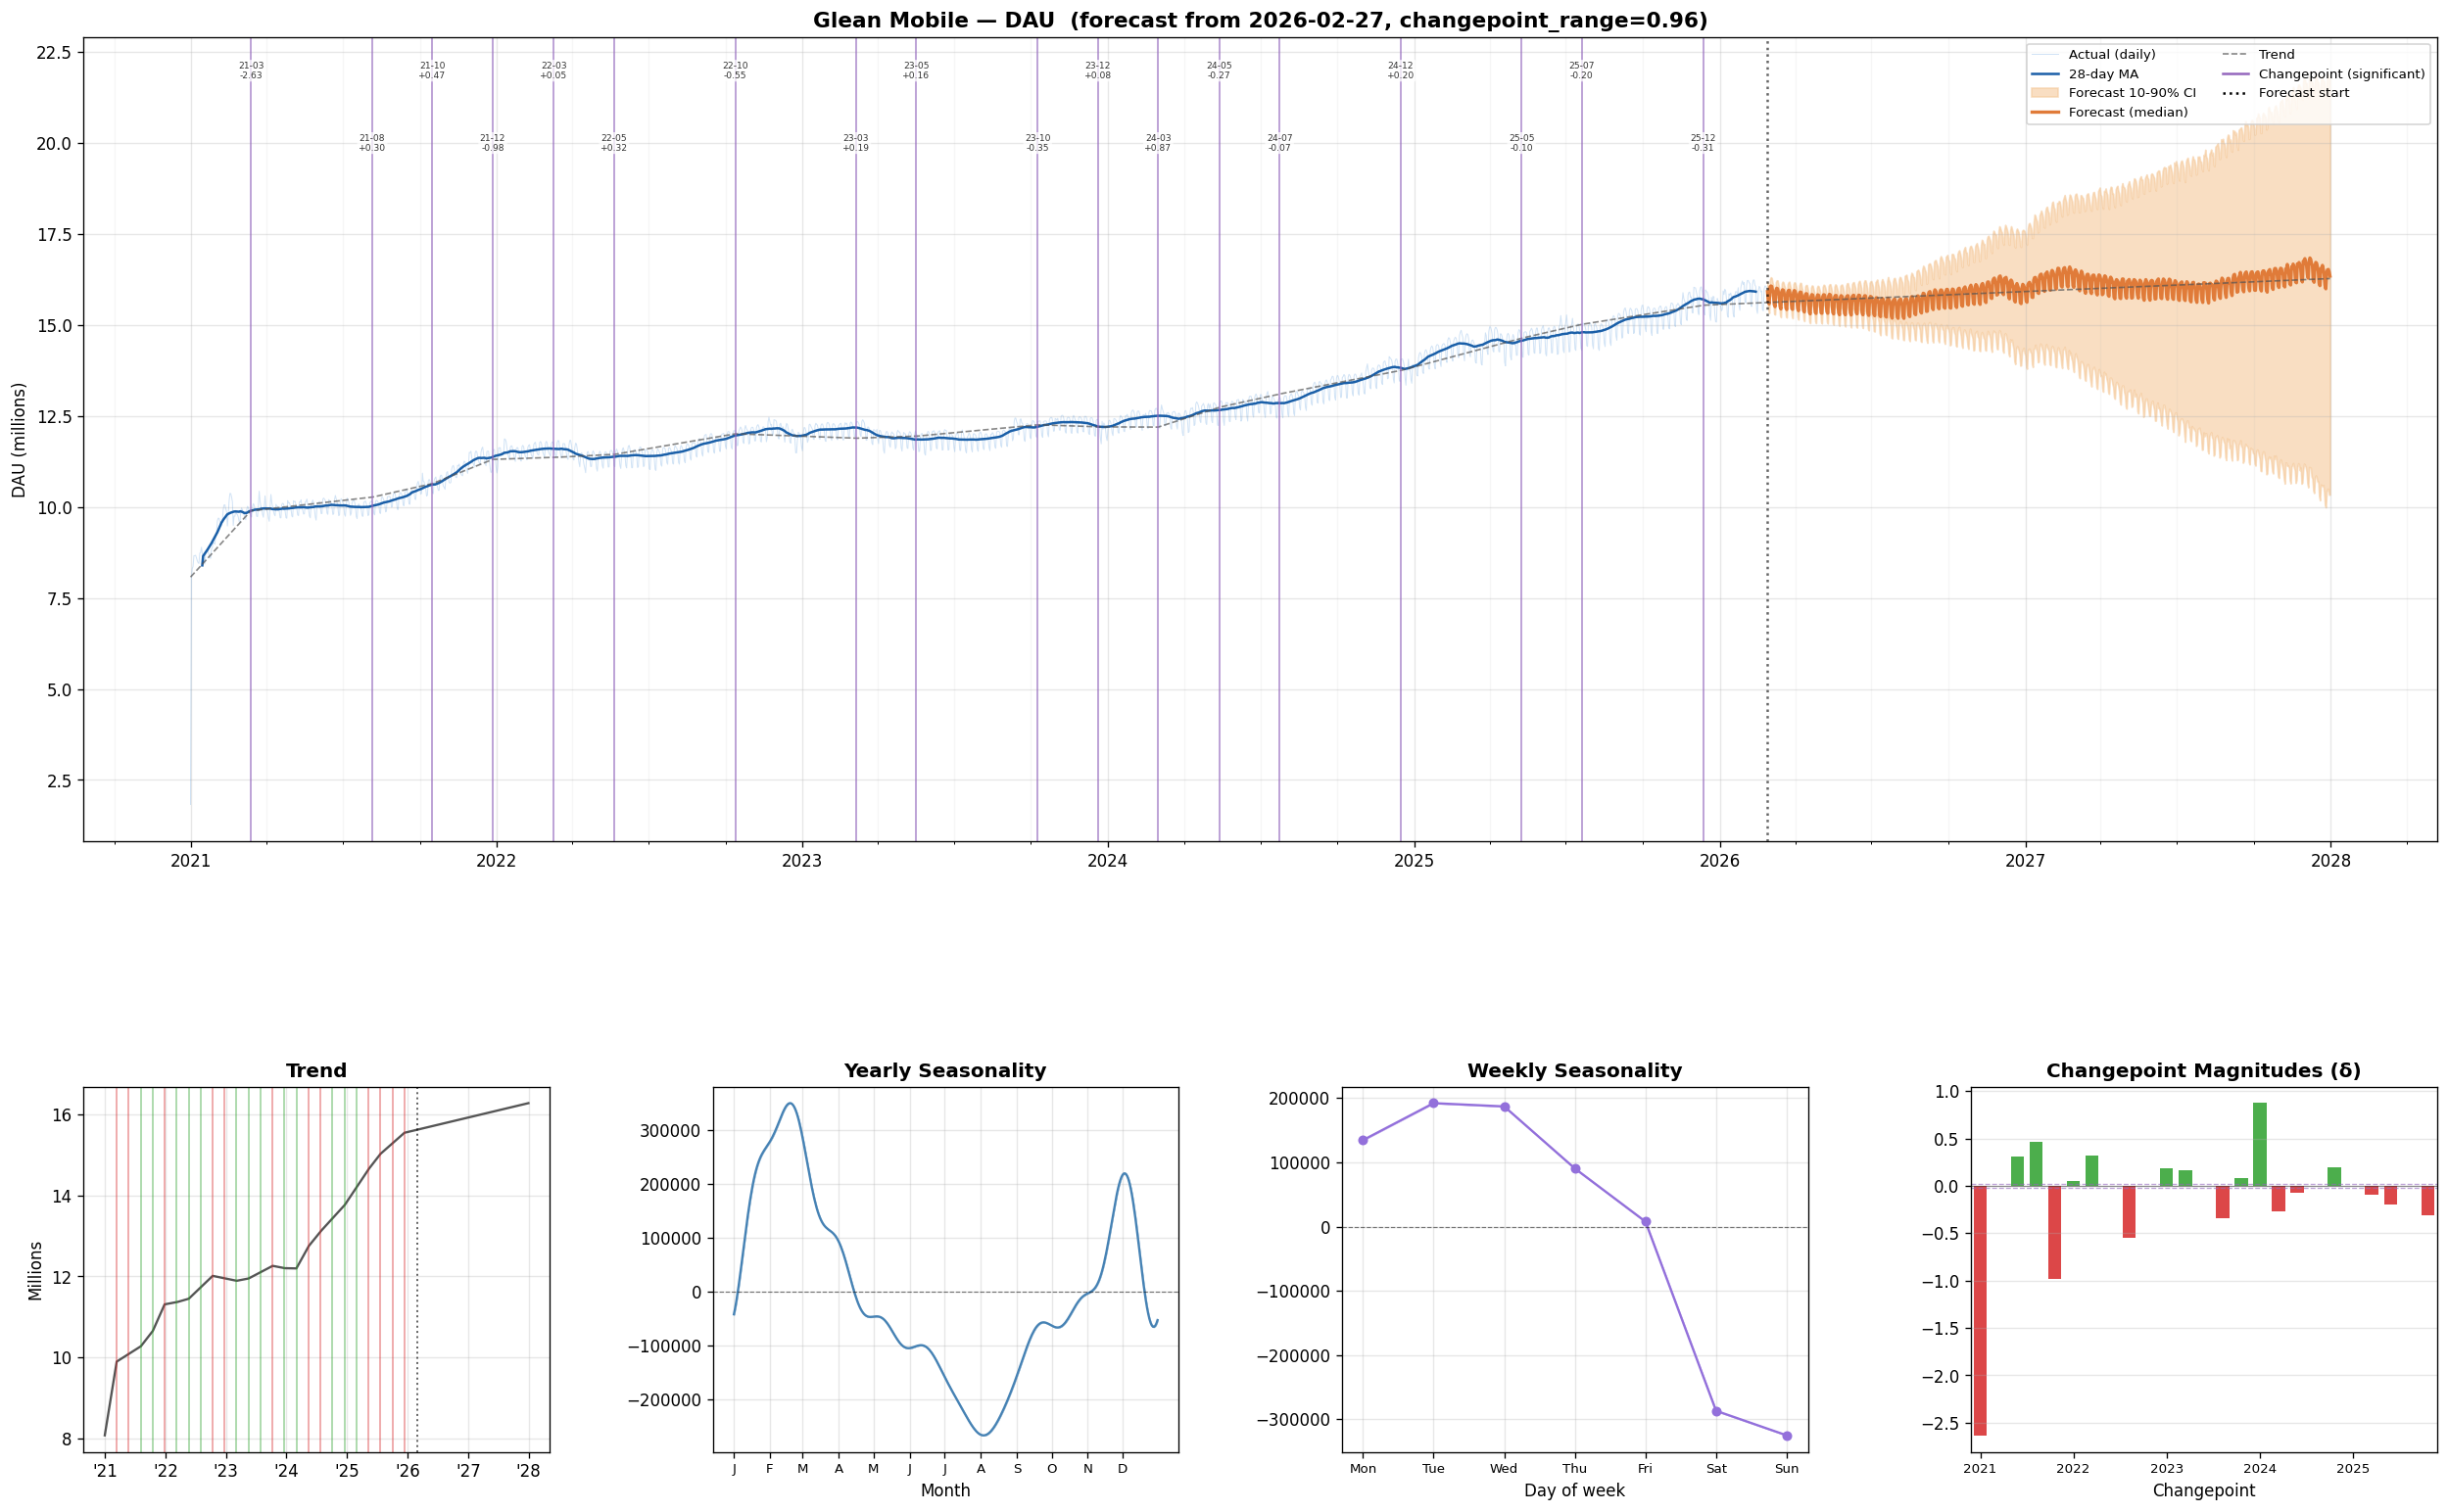

Computing predictions for: Legacy Desktop — DAU  (forecast from 2026-02-27, changepoint_range=0.96)
  Running in-sample predict()...
  Done (0.1s)
  Changepoints: 25 total, 13 significant (|delta| >= 0.002)
  Plot complete (0.2s)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

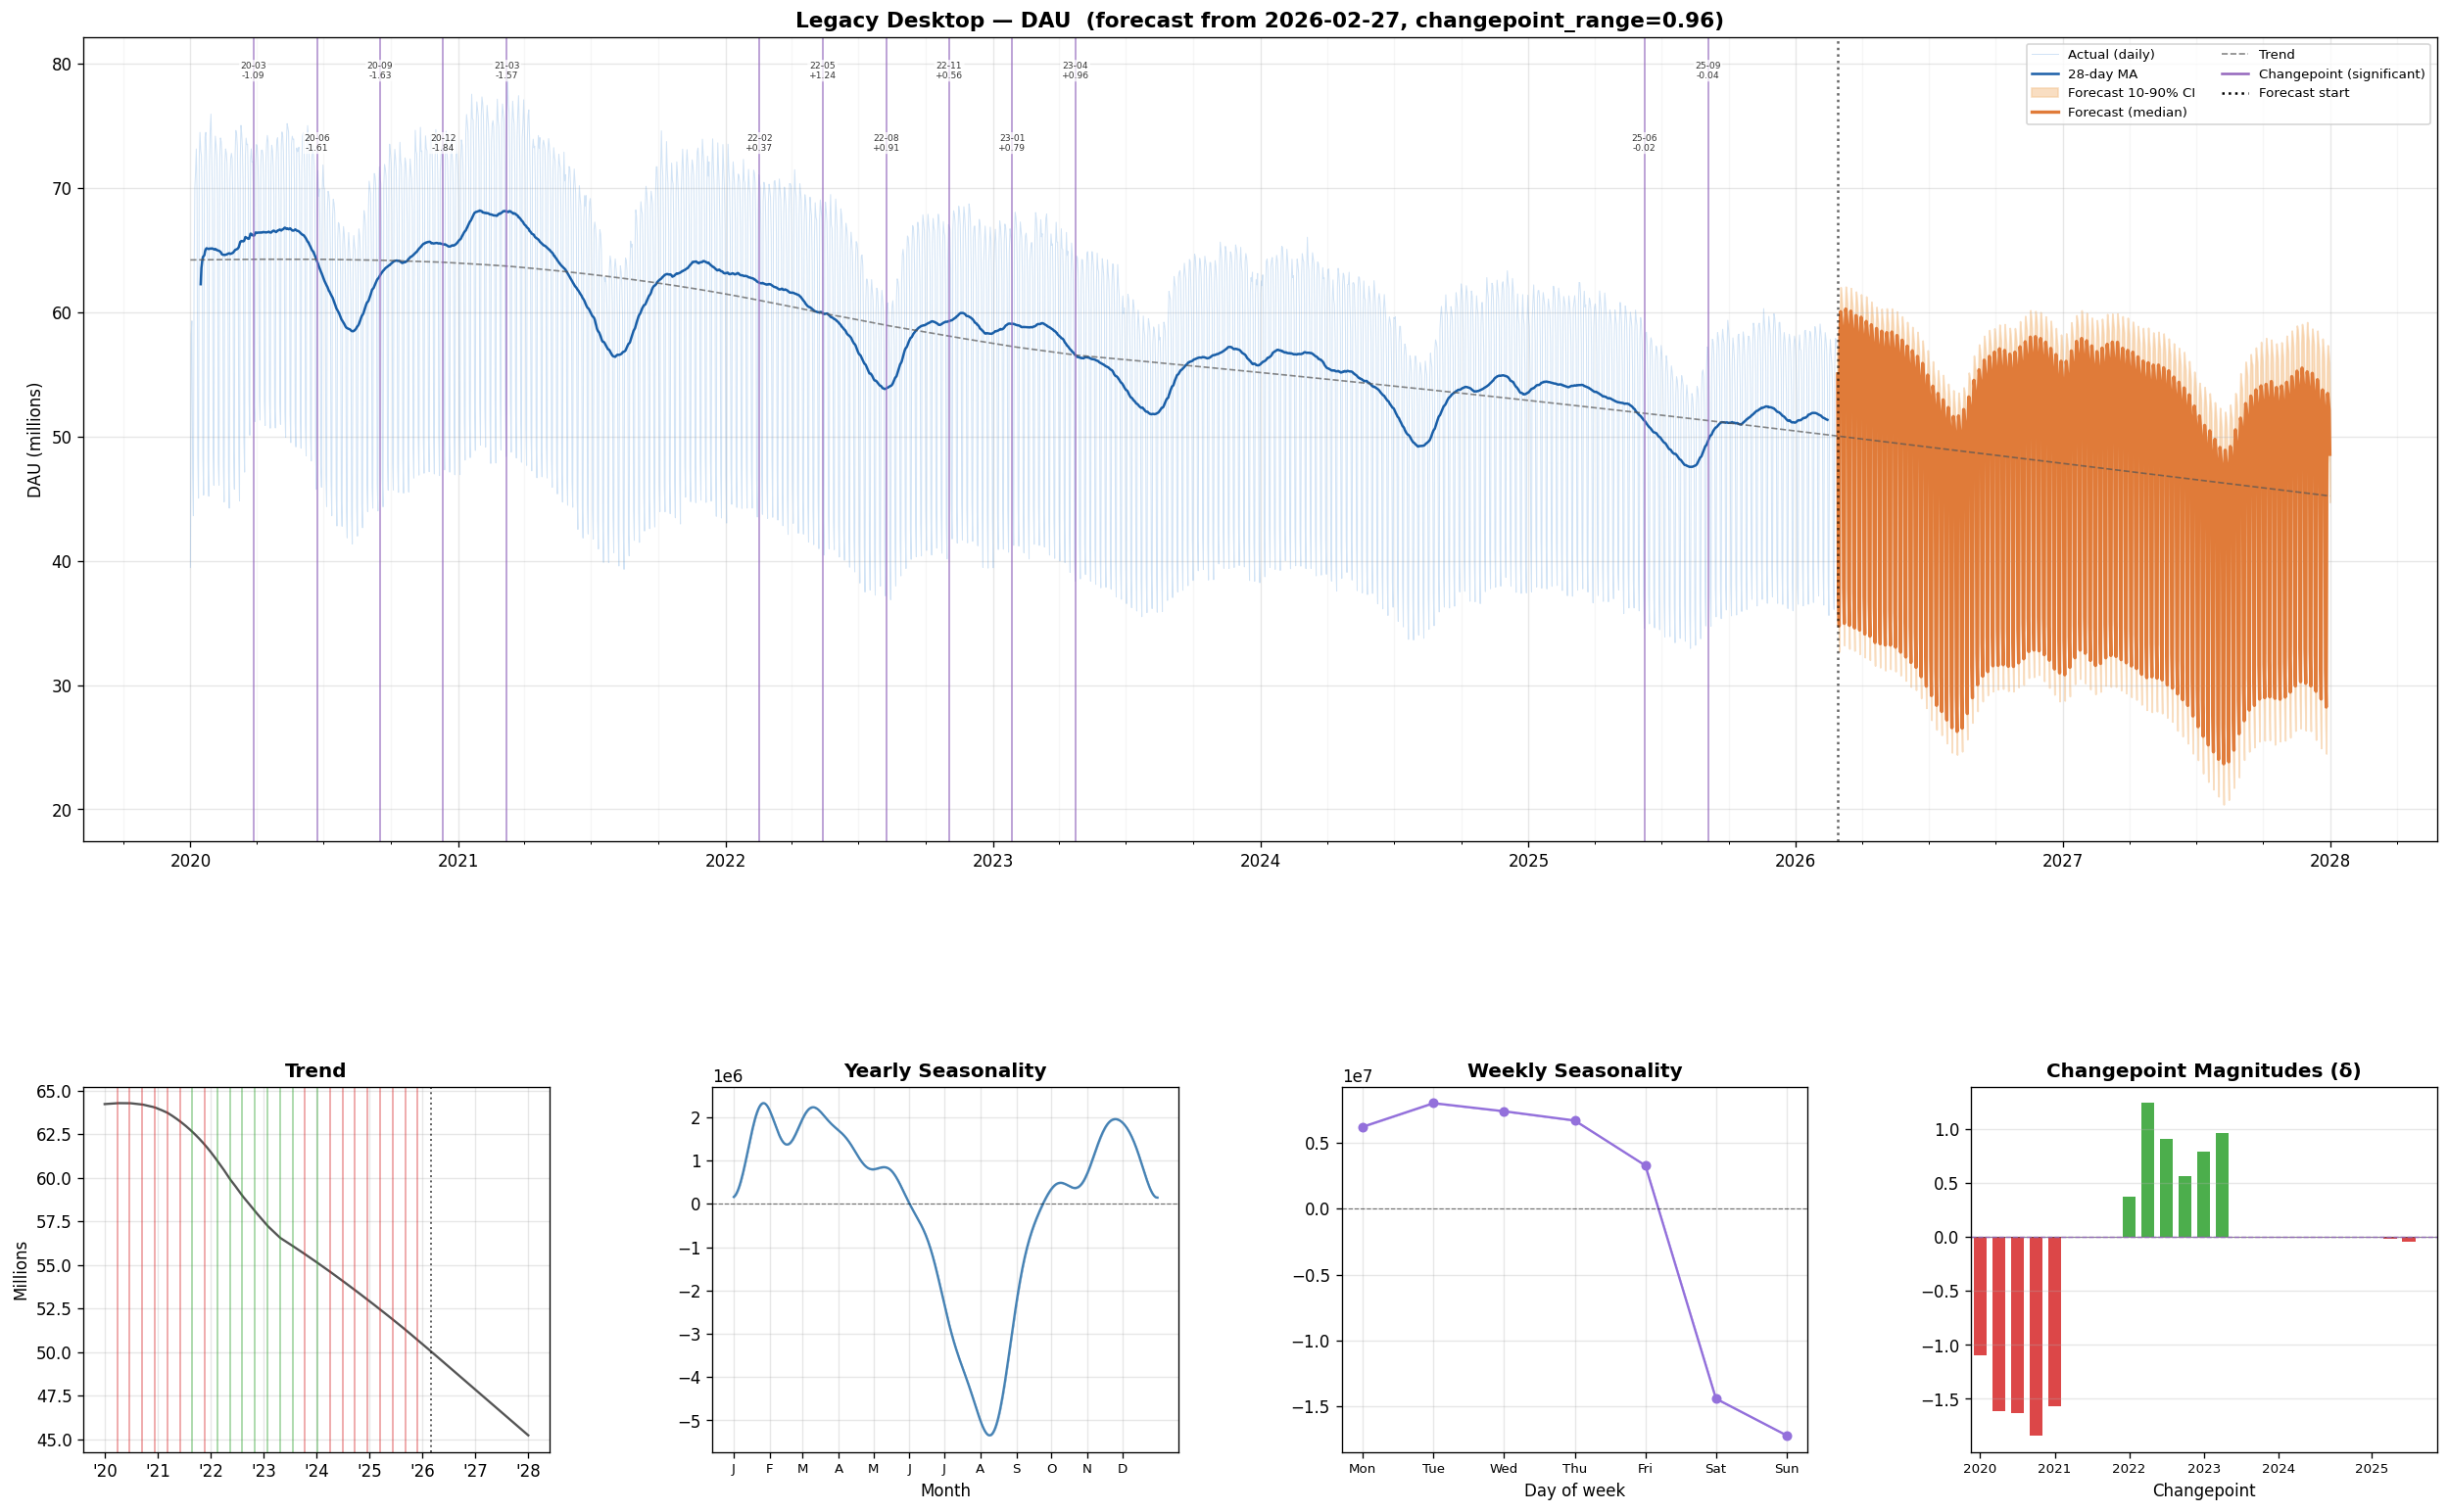

In [55]:
# [generate-plots-0.96]
for file_stem, mozaics_dict in all_mozaics_096.items():
    parts = file_stem.split('.')
    source_name = parts[1].replace('_', ' ').title() if len(parts) > 1 else file_stem
    forecast_date = parts[2] if len(parts) > 2 else ''

    for metric, moz in mozaics_dict.items():
        title = f"{source_name} — {metric}  (forecast from {forecast_date}, changepoint_range=0.96)"
        plot_mozaic_changepoints(moz, title=title)

---
## Trend Line Comparison: Default vs `changepoint_range=0.96`

Overlay plots and numerical comparison at a specific forecast date.

In [56]:
# [define-comparison-helpers]

COMPARISON_DATE = '2026-12-15'

# All versions to compare — add new entries here as more datasets are generated
VERSIONS = {
    'default': lambda: all_mozaics,
    '0.90':    lambda: all_mozaics_090,
    '0.96':    lambda: all_mozaics_096,
}
VERSION_COLORS = {
    'default': '#1a5fa8',
    '0.90':    '#2ca02c',
    '0.96':    '#d62728',
}
VERSION_FORECAST_COLORS = {
    'default': '#a8c8f0',
    '0.90':    '#a8f0b8',
    '0.96':    '#f0a8a8',
}


def get_full_trend_series(moz):
    """Return a DatetimeIndex-indexed Series of the full trend (historical + forecast)."""
    hist_pred = get_historical_predictions(moz)
    forecast_df = moz._prophet_forecast
    dates = pd.concat([hist_pred['ds'], forecast_df['ds']]).reset_index(drop=True)
    trend = pd.concat([hist_pred['trend'], forecast_df['trend']]).reset_index(drop=True)
    return pd.Series(trend.values, index=pd.to_datetime(dates))


def get_forecast_ma_series(moz, window=28):
    """Return a DatetimeIndex-indexed Series of the rolling mean of the forecast median."""
    forecast_dates = moz.forecast_dates
    forecast_median = moz.forecast.median(axis=1).values
    s = pd.Series(forecast_median, index=pd.to_datetime(forecast_dates))
    return s.rolling(window, center=True, min_periods=1).mean()


def get_source_mozaic_map(all_mozaics_dict):
    """Build a {source_name: {metric: mozaic}} mapping from the loaded all_mozaics dict."""
    result = {}
    for file_stem, mozaics_dict in all_mozaics_dict.items():
        parts = file_stem.split('.')
        source = parts[1] if len(parts) > 1 else file_stem
        result[source] = mozaics_dict
    return result


def value_at_date(series, target_date):
    """Return the series value at target_date, using nearest available date."""
    target = pd.Timestamp(target_date)
    idx = series.index.get_indexer([target], method='nearest')[0]
    return series.iloc[idx]


Computing trend series...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

  glean_mobile / DAU: done


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

  legacy_desktop / DAU: done


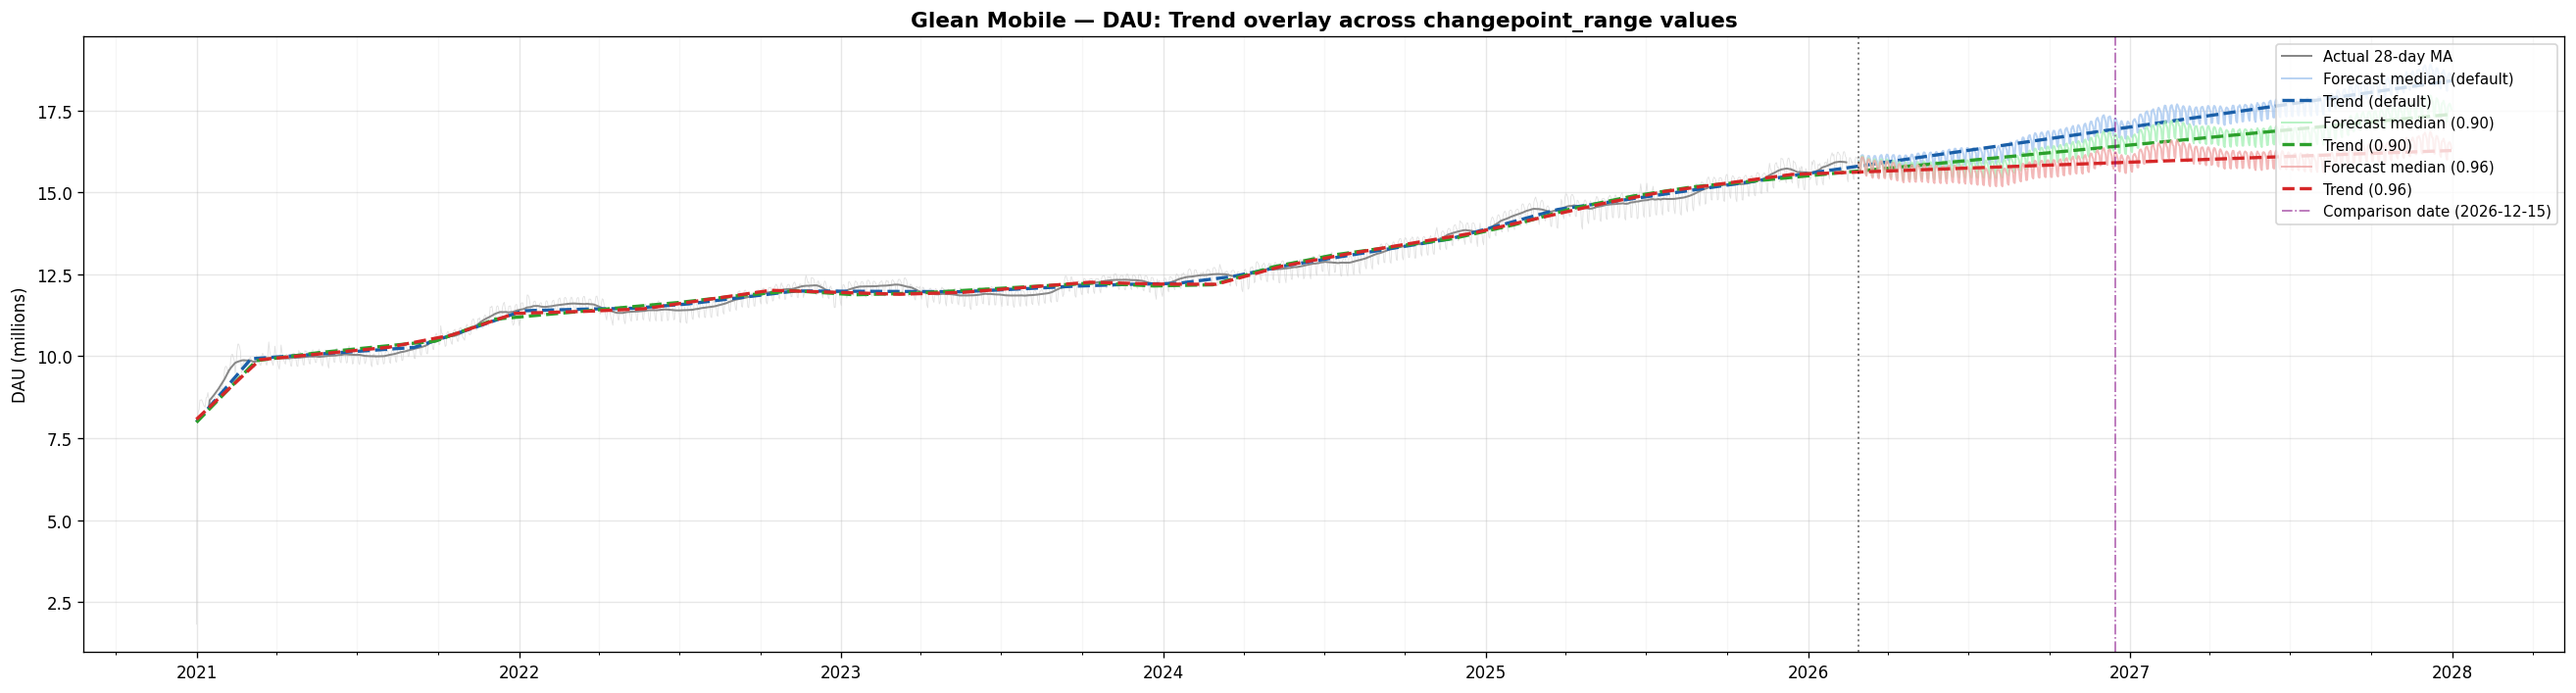

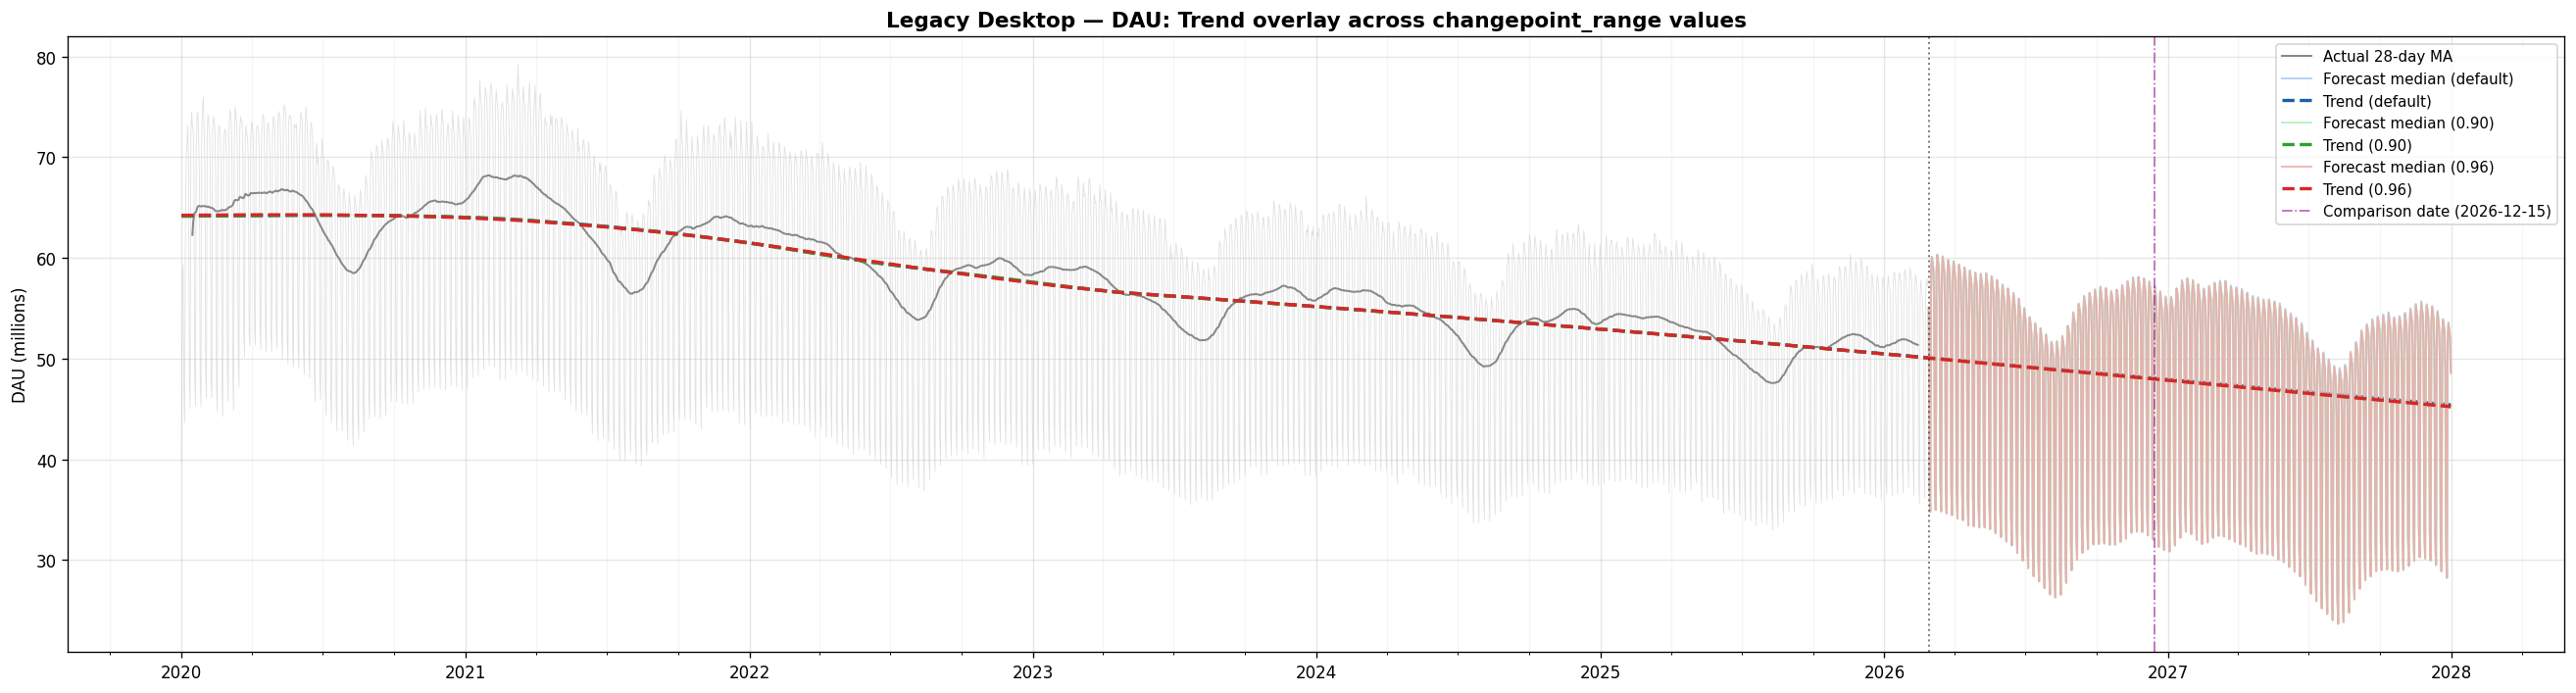

In [57]:
# [plot-trend-overlays]
source_labels = {'legacy_desktop': 'Legacy Desktop', 'glean_mobile': 'Glean Mobile'}

# Resolve version dicts (lambdas allow VERSIONS to reference vars defined after the helpers cell)
version_maps = {name: get_source_mozaic_map(loader()) for name, loader in VERSIONS.items()}

# Determine the set of sources present in all versions
common_sources = sorted(set.intersection(*[set(vm.keys()) for vm in version_maps.values()]))

# Pre-compute trend and forecast series for every version/source/metric
print("Computing trend series...")
trend_data = {}  # {source: {metric: {version: {'trend': series, 'fc_med': series}}}}
for source in common_sources:
    trend_data[source] = {}
    common_metrics = sorted(set.intersection(*[
        set(version_maps[v][source].keys()) for v in VERSIONS if source in version_maps[v]
    ]))
    for metric in common_metrics:
        trend_data[source][metric] = {}
        for version_name, source_map in version_maps.items():
            moz = source_map[source][metric]
            trend_data[source][metric][version_name] = {
                'trend':  get_full_trend_series(moz),
                'fc_med': pd.Series(
                    moz.forecast.median(axis=1).values,
                    index=pd.to_datetime(moz.forecast_dates)
                ),
            }
        print(f"  {source} / {metric}: done")

# One figure per source
for source in common_sources:
    label = source_labels.get(source, source)
    for metric, version_series in trend_data[source].items():
        # Use the default version's history (same training data across versions)
        default_moz = version_maps['default'][source][metric]
        hist = pd.Series(
            default_moz._prophet_model.history['y'].values,
            index=pd.to_datetime(default_moz._prophet_model.history['ds'])
        )
        hist_ma = hist.rolling(28, center=True).mean()
        fc_start = pd.Timestamp(default_moz.forecast_start_date)

        fig, ax = plt.subplots(figsize=(22, 6))

        # Historical actuals (shared across versions)
        ax.plot(hist.index, hist / 1e6, color='#cccccc', linewidth=0.5, alpha=0.6)
        ax.plot(hist_ma.index, hist_ma / 1e6, color='#888888', linewidth=1.2, label='Actual 28-day MA')

        # Per-version forecast medians and trend lines
        for version_name, series in version_series.items():
            color = VERSION_COLORS[version_name]
            fc_color = VERSION_FORECAST_COLORS[version_name]
            ax.plot(series['fc_med'].index, series['fc_med'] / 1e6,
                    color=fc_color, linewidth=1.2, alpha=0.8,
                    label=f'Forecast median ({version_name})')
            ax.plot(series['trend'].index, series['trend'] / 1e6,
                    color=color, linewidth=2.0, linestyle='--',
                    label=f'Trend ({version_name})')

        # Reference lines
        ax.axvline(fc_start, color='black', linewidth=1.2, linestyle=':', alpha=0.5)
        ax.axvline(pd.Timestamp(COMPARISON_DATE), color='purple', linewidth=1.0,
                   linestyle='-.', alpha=0.6, label=f'Comparison date ({COMPARISON_DATE})')

        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.set_ylabel('DAU (millions)')
        ax.set_title(
            f'{label} — {metric}: Trend overlay across changepoint_range values',
            fontsize=13, fontweight='bold'
        )
        ax.grid(True, which='major', alpha=0.3)
        ax.grid(True, which='minor', alpha=0.1)
        ax.legend(fontsize=9, loc='upper right')
        plt.tight_layout()
        plt.show()


In [58]:
# [compare-at-date]
print(f"Numerical comparison at {COMPARISON_DATE}\n")

# Header
version_names = list(VERSIONS.keys())
header = f"{'Source':<18} {'Metric':<8}"
for v in version_names:
    header += f" {'Trend '+v:>14}"
for i in range(1, len(version_names)):
    header += f" {'Δtrend vs def':>14}"
for v in version_names:
    header += f" {'MA '+v:>12}"
for i in range(1, len(version_names)):
    header += f" {'ΔMA vs def':>12}"
print(header)
print('-' * (18 + 8 + 14 * len(version_names) + 14 * (len(version_names)-1) +
             12 * len(version_names) + 12 * (len(version_names)-1) + 2))

rows = []
for source in common_sources:
    label = source_labels.get(source, source)
    for metric in trend_data[source]:
        row = {'source': label, 'metric': metric}

        # Trend values at comparison date
        trend_vals = {}
        for v in version_names:
            trend_series = trend_data[source][metric][v]['trend']
            trend_vals[v] = value_at_date(trend_series, COMPARISON_DATE)
            row[f'trend_{v}_M'] = round(trend_vals[v] / 1e6, 3)

        # MA values at comparison date
        ma_vals = {}
        for v in version_names:
            moz = version_maps[v][source][metric]
            ma_vals[v] = value_at_date(get_forecast_ma_series(moz), COMPARISON_DATE)
            row[f'ma_{v}_M'] = round(ma_vals[v] / 1e6, 3)

        # Diffs vs default
        for v in version_names[1:]:
            row[f'trend_diff_{v}_M'] = round((trend_vals[v] - trend_vals['default']) / 1e6, 3)
            row[f'ma_diff_{v}_M']    = round((ma_vals[v] - ma_vals['default']) / 1e6, 3)

        line = f"{label:<18} {metric:<8}"
        for v in version_names:
            line += f" {trend_vals[v]/1e6:>12.2f}M"
        for v in version_names[1:]:
            line += f" {(trend_vals[v]-trend_vals['default'])/1e6:>+13.2f}M"
        for v in version_names:
            line += f" {ma_vals[v]/1e6:>10.2f}M"
        for v in version_names[1:]:
            line += f" {(ma_vals[v]-ma_vals['default'])/1e6:>+11.2f}M"
        print(line)
        rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df


Numerical comparison at 2026-12-15

Source             Metric    Trend default     Trend 0.90     Trend 0.96  Δtrend vs def  Δtrend vs def   MA default      MA 0.90      MA 0.96   ΔMA vs def   ΔMA vs def
--------------------------------------------------------------------------------------------------------------------------------------------------------------
Glean Mobile       DAU             16.93M        16.40M        15.91M         -0.53M         -1.02M      17.06M      16.58M      16.04M       -0.48M       -1.02M
Legacy Desktop     DAU             48.05M        47.96M        47.96M         -0.10M         -0.09M      49.15M      49.05M      49.07M       -0.10M       -0.08M


,source,metric,trend_default_M,trend_0.90_M,trend_0.96_M,ma_default_M,ma_0.90_M,ma_0.96_M,trend_diff_0.90_M,ma_diff_0.90_M,trend_diff_0.96_M,ma_diff_0.96_M
0,Glean Mobile,DAU,16.930,16.403,15.906,17.058,16.581,16.035,-0.527,-0.477,-1.024,-1.023
1,Legacy Desktop,DAU,48.051,47.956,47.958,49.148,49.051,49.071,-0.095,-0.097,-0.093,-0.077
